# 1 Importing Necessary Libraries and Downloading the Dataset

In this first step, we will import the necessary libraries and download the latest version of the dataset into the folder where this notebook is located.

Since the dataset is too large to work with, we will filter the data to include only the following applications:
- YOUTUBE
- AMAZON
- GMAIL
- WINDOWS UPDATE
- SKYPE
- FACEBOOK
- DROPBOX
- YAHOO
- TWITTER
- MSN



# Data Acquisition & Data Preprocessing

## 2.1 Dataset Acquisition

Reading the dataset and using only the specified apps

In [1]:
import pandas as pd

# you can find the dataset on this link: https://www.kaggle.com/datasets/jsrojas/ip-network-traffic-flows-labeled-with-87-apps?resource=download
dataframe = pd.read_csv('Dataset-Unicauca-Version2-87Atts.csv')

apps_of_interest = [
    'YOUTUBE', 'AMAZON', 'GMAIL', 'WINDOWS_UPDATE', 'SKYPE', 'FACEBOOK', 'DROPBOX', 'YAHOO', 'TWITTER', 'MSN'
]

In [2]:
filtered_df = dataframe[dataframe['ProtocolName'].isin(apps_of_interest)].copy()
filtered_df.to_csv('Dataset-Unicauca-Version2-87Atts_reduced.csv', index=False)

## 2.2 Data Preprocessing

In [3]:
import pandas as pd
df = pd.read_csv('Dataset-Unicauca-Version2-87Atts_reduced.csv')
df.info()
df['ProtocolName'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 471184 entries, 0 to 471183
Data columns (total 87 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Flow.ID                      471184 non-null  object 
 1   Source.IP                    471184 non-null  object 
 2   Source.Port                  471184 non-null  int64  
 3   Destination.IP               471184 non-null  object 
 4   Destination.Port             471184 non-null  int64  
 5   Protocol                     471184 non-null  int64  
 6   Timestamp                    471184 non-null  object 
 7   Flow.Duration                471184 non-null  int64  
 8   Total.Fwd.Packets            471184 non-null  int64  
 9   Total.Backward.Packets       471184 non-null  int64  
 10  Total.Length.of.Fwd.Packets  471184 non-null  int64  
 11  Total.Length.of.Bwd.Packets  471184 non-null  float64
 12  Fwd.Packet.Length.Max        471184 non-null  int64  
 13 

ProtocolName
YOUTUBE           170781
AMAZON             86875
GMAIL              40260
WINDOWS_UPDATE     34471
SKYPE              30657
FACEBOOK           29033
DROPBOX            25102
YAHOO              21268
TWITTER            18259
MSN                14478
Name: count, dtype: int64

Now we perform some feature conversion, type that can be more understandable for our Model

In [4]:
# removing feature with only one value
col_to_rem = df.columns[df.nunique() == 1]
print("Eliminated feature with only one value: ", list(col_to_rem))
df_filtered = df.drop(columns=col_to_rem)

# removing redundant features
df1 = df_filtered.drop(columns=['Flow.ID', 'L7Protocol'])

# convert IP addresses in int, source = https://www.mohammedalani.com/tutorials/handling-ip-addresses-in-machine-learning-datasets/
def ip_to_int(ip):
    parts = ip.split('.')
    return (int(parts[0]) << 24) + (int(parts[1]) << 16) + (int(parts[2]) << 8) + int(parts[3])
df1['Source.IP'] = df1['Source.IP'].apply(ip_to_int)
df1['Destination.IP'] = df1['Destination.IP'].apply(ip_to_int)

# one-hot encoding
df1 = pd.get_dummies(df1, columns=['Protocol'], prefix='TransportProtocol')

# time conversion
df1['Timestamp'] = pd.to_datetime(df1['Timestamp'], format='%d/%m/%Y%H:%M:%S')
df1['Year'] = df1['Timestamp'].dt.year
df1['Month'] = df1['Timestamp'].dt.month
df1['Day'] = df1['Timestamp'].dt.day
df1['Hour'] = df1['Timestamp'].dt.hour
df1['Minute'] = df1['Timestamp'].dt.minute
df1['Second'] = df1['Timestamp'].dt.second
# convertion of timestamp in seconds, counting from 1970-01-01
df1['Timestamp'] = (df1['Timestamp'] - pd.Timestamp("1970-01-01")) // pd.Timedelta('1s')

print("List of features: ", list(df1.columns))
print("Shape of the dataset: ", df1.shape)

Eliminated feature with only one value:  ['Bwd.PSH.Flags', 'Fwd.URG.Flags', 'Bwd.URG.Flags', 'CWE.Flag.Count', 'Fwd.Avg.Bytes.Bulk', 'Fwd.Avg.Packets.Bulk', 'Fwd.Avg.Bulk.Rate', 'Bwd.Avg.Bytes.Bulk', 'Bwd.Avg.Packets.Bulk', 'Bwd.Avg.Bulk.Rate', 'Label']
List of features:  ['Source.IP', 'Source.Port', 'Destination.IP', 'Destination.Port', 'Timestamp', 'Flow.Duration', 'Total.Fwd.Packets', 'Total.Backward.Packets', 'Total.Length.of.Fwd.Packets', 'Total.Length.of.Bwd.Packets', 'Fwd.Packet.Length.Max', 'Fwd.Packet.Length.Min', 'Fwd.Packet.Length.Mean', 'Fwd.Packet.Length.Std', 'Bwd.Packet.Length.Max', 'Bwd.Packet.Length.Min', 'Bwd.Packet.Length.Mean', 'Bwd.Packet.Length.Std', 'Flow.Bytes.s', 'Flow.Packets.s', 'Flow.IAT.Mean', 'Flow.IAT.Std', 'Flow.IAT.Max', 'Flow.IAT.Min', 'Fwd.IAT.Total', 'Fwd.IAT.Mean', 'Fwd.IAT.Std', 'Fwd.IAT.Max', 'Fwd.IAT.Min', 'Bwd.IAT.Total', 'Bwd.IAT.Mean', 'Bwd.IAT.Std', 'Bwd.IAT.Max', 'Bwd.IAT.Min', 'Fwd.PSH.Flags', 'Fwd.Header.Length', 'Bwd.Header.Length', 'Fwd.

Splitting the data for training and test, converting feature and scaling

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

y = pd.get_dummies(df1['ProtocolName'], prefix='ProtocolName').to_numpy()       # target = Application
X = pd.DataFrame(df1, columns=df1.drop(columns=['ProtocolName']).columns)       # features

#splitting data for training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# scaling data in [0,1] interval
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
# converting y_train in DataFrame
y_train_df = pd.DataFrame(y_train, columns=[f'ProtocolName_{i}' for i in range(y_train.shape[1])])

# convertion in dataframe for simpler manipulation
X_train_scaled_tmp_df = pd.DataFrame(X_train_scaled, columns=df1.drop(columns=['ProtocolName']).columns) 
x_test_scaled_df = pd.DataFrame(X_test_scaled, columns=df1.drop(columns=['ProtocolName']).columns)


# 2.3 Exploratory Data Analysis
Visualization of the correlation matrix and removal of the features with correlation > 0.8

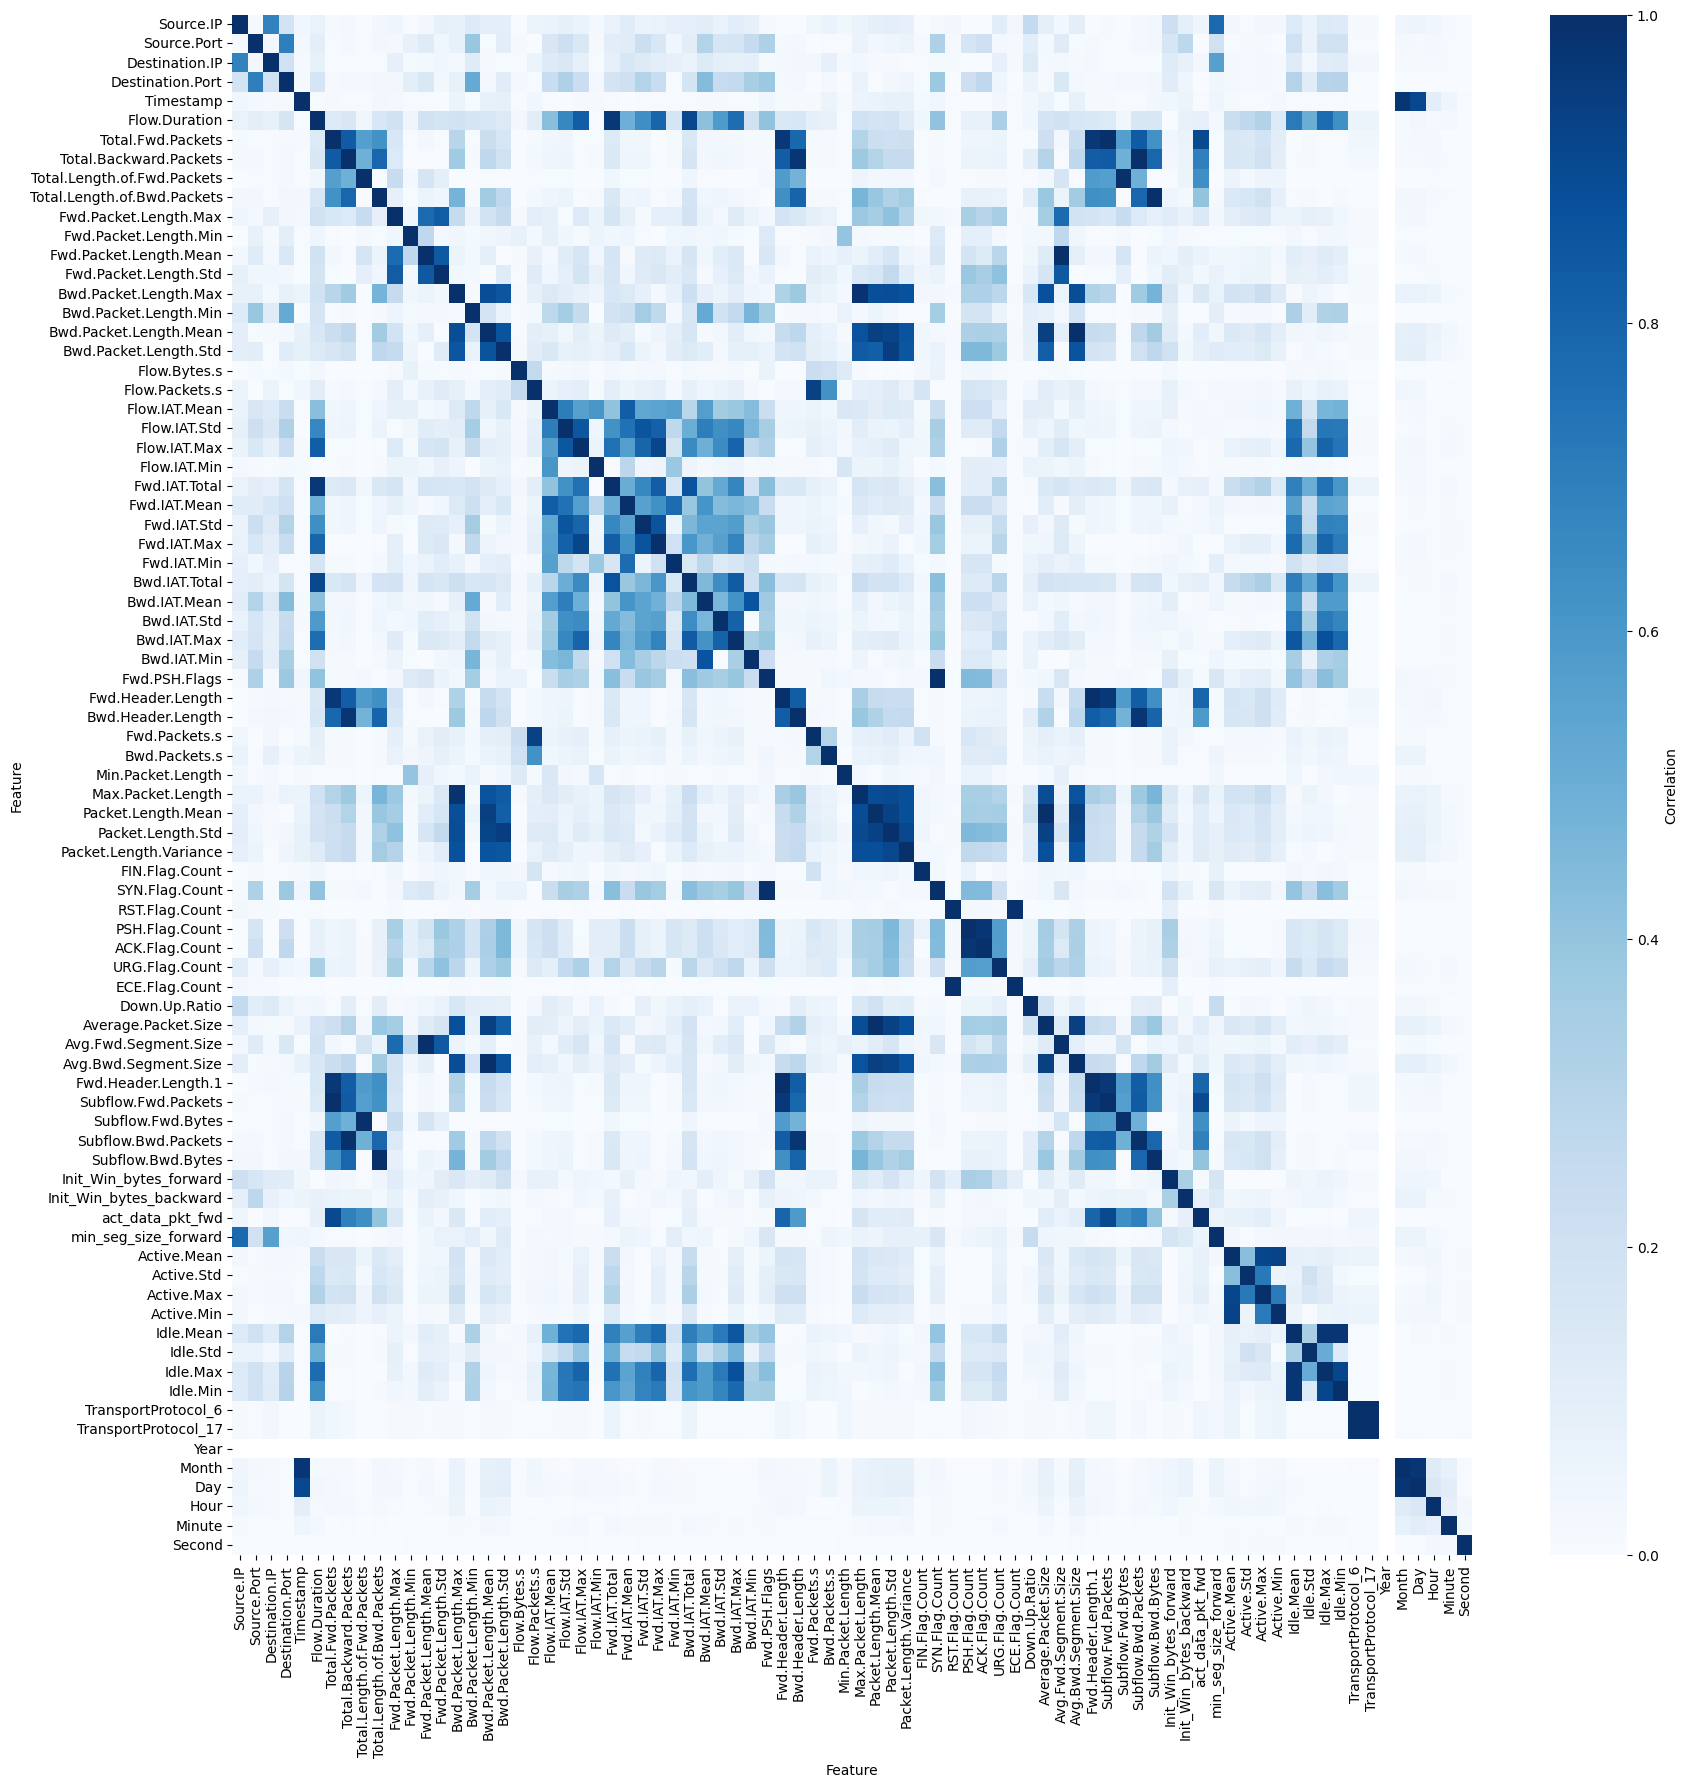

40 features are removed
Deleted features:  ['Fwd.Packet.Length.Mean', 'Avg.Fwd.Segment.Size', 'Bwd.Packet.Length.Mean', 'Avg.Bwd.Segment.Size', 'TransportProtocol_6', 'Total.Length.of.Bwd.Packets', 'Total.Length.of.Fwd.Packets', 'Subflow.Bwd.Bytes', 'Subflow.Fwd.Packets', 'Fwd.Header.Length.1', 'Subflow.Bwd.Packets', 'SYN.Flag.Count', 'Fwd.Header.Length', 'Total.Backward.Packets', 'Total.Fwd.Packets', 'Average.Packet.Size', 'Packet.Length.Mean', 'ECE.Flag.Count', 'Bwd.Packet.Length.Max', 'Max.Packet.Length', 'PSH.Flag.Count', 'Day', 'Month', 'Idle.Mean', 'Idle.Max', 'Flow.Duration', 'Fwd.IAT.Total', 'Packet.Length.Std', 'Bwd.Packet.Length.Std', 'Flow.Packets.s', 'Active.Min', 'Active.Mean', 'Fwd.IAT.Max', 'Flow.IAT.Max', 'Bwd.IAT.Total', 'Bwd.IAT.Max', 'Bwd.IAT.Mean', 'Fwd.IAT.Std', 'Fwd.Packet.Length.Std', 'Flow.IAT.Mean']


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

feature_names = X_train.columns.tolist()

columns = [i for i in range(X_train_scaled.shape[1])]
df_tmp = pd.DataFrame(X_train_scaled, columns=columns)
correlation_matrix = df_tmp.corr().abs()

# Display the heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, cmap='Blues', vmin=0, vmax=1, cbar_kws={'label':'Correlation'}, xticklabels=feature_names, yticklabels=feature_names)
plt.xlabel('Feature')
plt.ylabel('Feature')
plt.show()

# Extract features having a correlation > 0.8
c = correlation_matrix[correlation_matrix > 0.8]
s = c.unstack()
so = s.sort_values(ascending=False).reset_index()

# Get strongly correlated features, removing pairs having correlation = 1 because of the diagonal, i.e., correlation between one feature and itself
so = so[(so[0].isnull() == False) & (so["level_0"] != so["level_1"])]

to_be_deleted = []
candidates = list(so["level_0"].unique())

# Get the unique set of features to be deleted. Notice that we discard one feature per time considering the case where a feature is strongly correlated with multiple features
subset_so = so
for candidate in candidates:
    if candidate in list(subset_so["level_0"]):
        to_be_deleted.append(candidate)
        subset_so = subset_so[(subset_so["level_0"] != candidate) & (subset_so["level_1"] != candidate)]

# Create a mask for the columns to keep
columns_to_keep = np.ones(X_train_scaled.shape[1], dtype=bool)
columns_to_keep[to_be_deleted] = False

# to_be_deleted contains the index of columns that you need to remove from both training and test sets
print(len(to_be_deleted), 'features are removed')

# Use the mask to select only the columns to keep
X_train_scaled = X_train_scaled[:, columns_to_keep]
X_test_scaled = X_test_scaled[:, columns_to_keep]

# dataframe with the features to keep
deleted_feature_names = [X_train_scaled_tmp_df.columns[i] for i in to_be_deleted]
X_train_scaled_df = X_train_scaled_tmp_df.drop(columns=deleted_feature_names, inplace=False) # dataframe with the features to keep
x_test_scaled_df = x_test_scaled_df.drop(columns=deleted_feature_names, inplace=False) # dataframe with the features to keep

print("Deleted features: ", deleted_feature_names)

### Boxplot

For visualizing the dataset's patterns using box plots, we only plot the most significative features.

In [7]:
remove = []

# Remove converted feature that were categorical and temporal ones
catTemp_columns = ['Source.IP', 'Destination.IP', 'Protocol', 'Label', 'Timestamp', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second', 'Timestamp']
remove.extend(filter(lambda el: el in X_train_scaled_df.columns, catTemp_columns))


# Remove columns with binary flags
binary_columns = ['Fwd.PSH.Flags', 'FIN.Flag.Count', 'PSH.Flag.Count', 'URG.Flag.Count', 'ECE.Flag.Count', 'ACK.Flag.Count']
remove.extend(filter(lambda el: el in X_train_scaled_df.columns, binary_columns))

# Other not significative features
columns = ['TransportProtocol_17', 'Flow.Bytes.s', 'Flow.Packets.s', 'Flow.IAT.Mean', 'Fwd.IAT.Mean', 'Bwd.IAT.Min', 'Fwd.Packets.s',
           'Flow.IAT.Min', 'Fwd.IAT.Min', 'Bwd.Header.Length', 'Bwd.Packets.s', 'Down.Up.Ratio', 'Subflow.Fwd.Bytes', 'Init_Win_bytes_backward',
           'act_data_pkt_fwd', 'Active.Max', 'Active.Min', 'Packet.Length.Variance', 'Fwd.Packet.Length.Max', 'min_seg_size_forward', 'Bwd.IAT.Mean']
remove.extend(filter(lambda el: el in X_train_scaled_df.columns, columns))

# Remove columns with all the same values
constant_columns = [col for col in X_train_scaled_df.columns if X_train_scaled_df[col].nunique() == 1]
remove.extend(filter(lambda el: el in X_train_scaled_df.columns, constant_columns))


# Remove really sparse features
sparsity = (X_train_scaled_df == 0).mean()
sparse_features = sparsity[sparsity > 0.8].index.to_list()
remove.extend(filter(lambda el: el in X_train_scaled_df.columns, sparse_features))


X_train_scaled_box_df = X_train_scaled_df.drop(columns=remove)
y_train_reconstructed = pd.DataFrame(y_train, columns=pd.get_dummies(df1['ProtocolName']).columns).idxmax(axis=1)

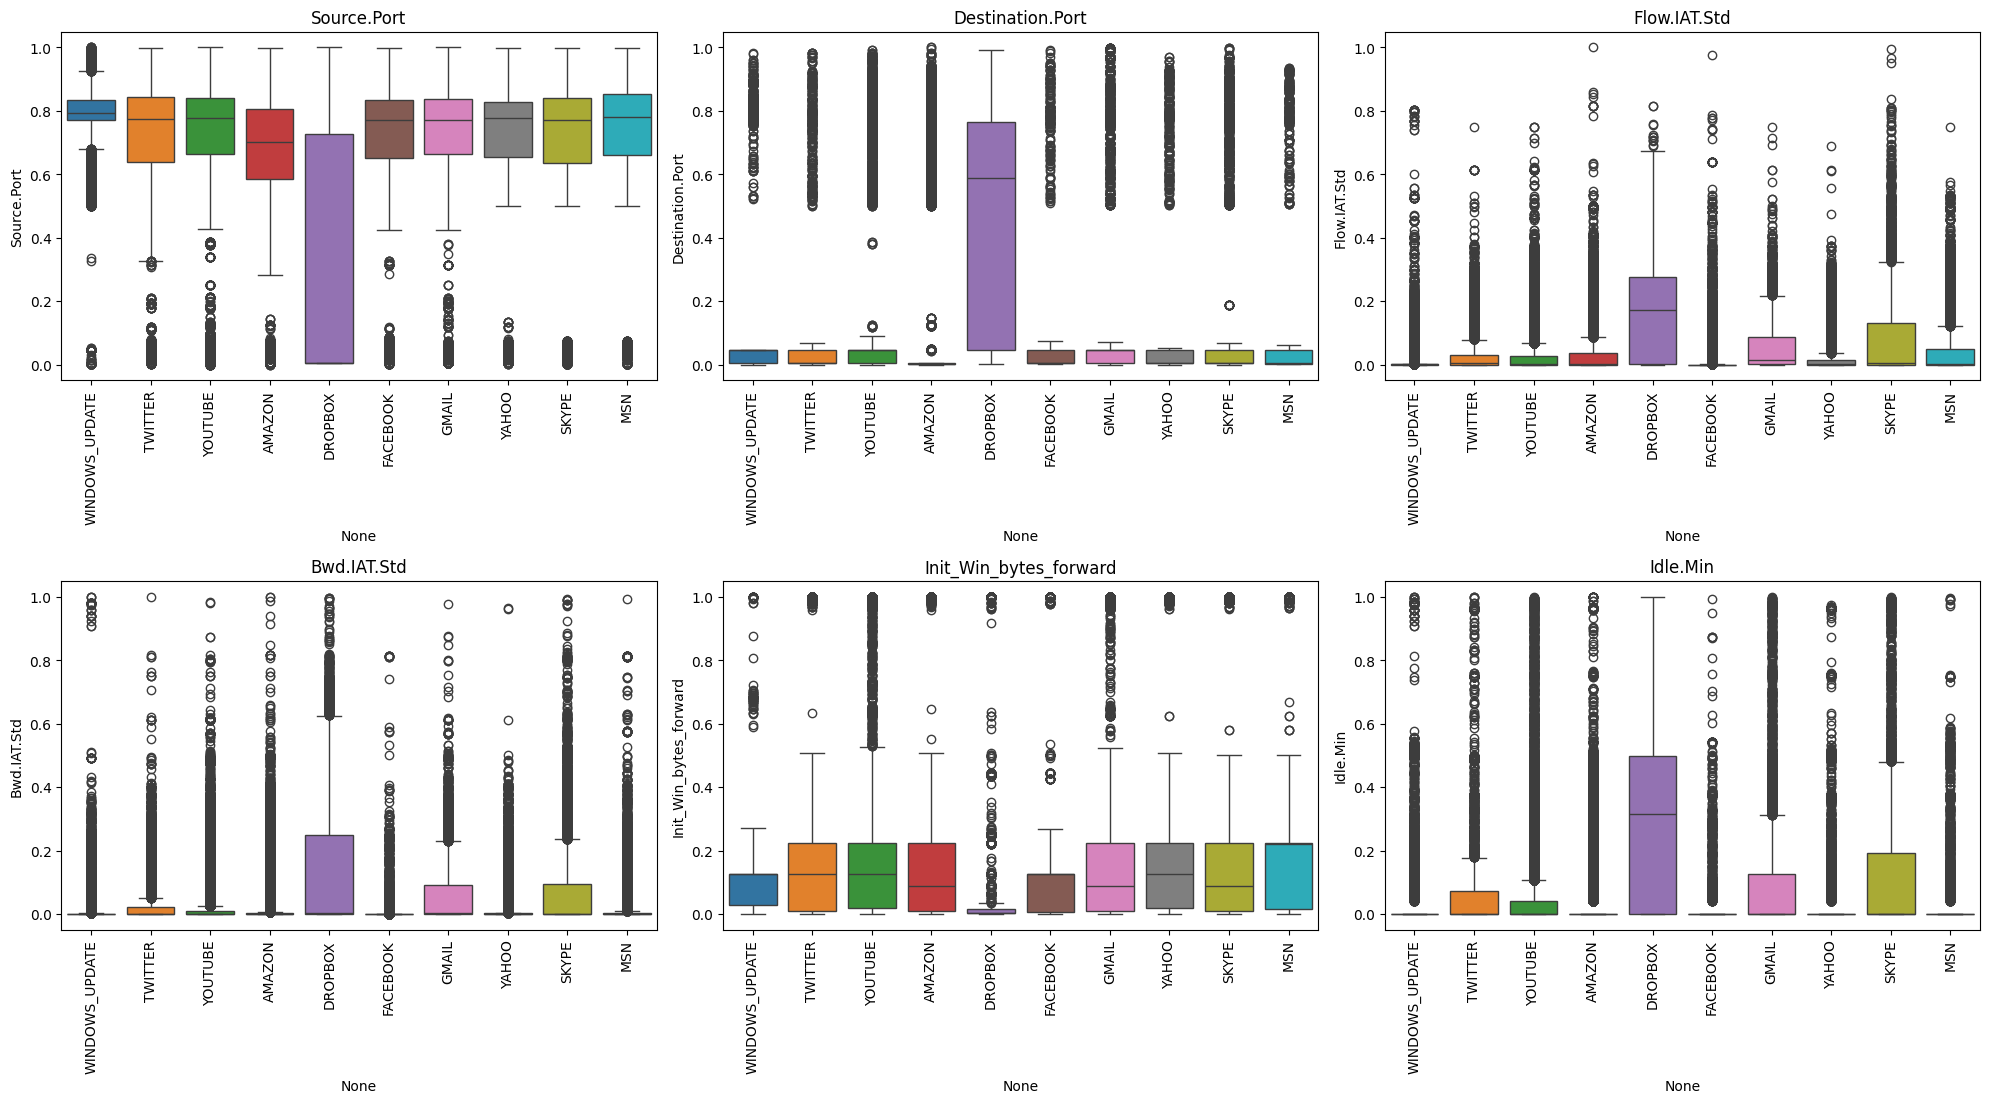

In [8]:
# un boxplot per ogni feature
plt.figure(figsize=(20, 15))
num_features = X_train_scaled_box_df.shape[1] + 1

for i, feature in enumerate(X_train_scaled_box_df.columns):
    plt.subplot(int(num_features/2),3, i+1)
    sns.boxplot(x=y_train_reconstructed, y=feature, data=X_train_scaled_df, hue=y_train_reconstructed, palette='tab10')
    plt.title(f'{feature}')
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Observations

1. Source.Port

Dropbox has the highest interquartile range, meaning that it uses a broader range of source ports, while Windows Update has the lowest one.  
The majority of the applications has a considerable number of outlier in the lower end of the range. These ports could be used during specific sessions or anomalies in the traffic.  
Also many applications have a median source port in the upper half of the range, which may indicate a common usage of Dynamic Ports, which are a subset of network ports used for short-lived communications, enabling client-server communication for applications such as web browsing, email, and file transfers.

2. Destination.Port

Similarly to the Source Port boxplot, we can see that Dropbox has the largest IRQ, while the others have much narrower distributions.  
This likely means that Dropbox uses multiple protocols and dynamic ports to facilitate file synchronization and data transfers.  
In this boxplot the outliers are mostly located in the upper end of the range and the median values are near zero.

3. Flow.IAT.Std (Inter-Arrival Time Standard Deviation)

Dropbox shows the largest IQR and higher median compared to other applications. This might be because Dropbox experiences irregular flow timings due to the nature of file synchronization, where data transfers occur in bursts.  
Other applications have much smaller IQRs and lower medians, indicating more consistent inter-arrival times, which is typical of real-time and streaming applications.  
All apllications have outliers, which could be the result from network congestion, retries, or less frequent data exchanges.

4. Bwd.IAT.Std (Backward Inter-Arrival Time Standard Deviation) 

Dropbox has the widest IQR and the highest median, while others are narrower and with lower medians.
Applications with low variability, such as Twitter and Gmail, can likely be optimized for consistent performance, while high variability applications like Dropbox might benefit from adaptive resource allocation to handle bursts efficiently.
Outliers are present for all applications, particularly in Amazon, Skype, and Dropbox.

5. Init_Win_bytes_forward (Initial Window Size (bytes) for forward traffic in a TCP connection)

Most applications have similar distributions, with medians around the lower half of the scale. Dropbox is the application with the smallest IRQ and lowest median.  
All applications have quite a large number of outliers.

6. Idle.Min (Minimum Idle Time)

Some applications like Dropbox, Skype and Gmail have wider IQRs, while most of them have very narrow ones.  
All categories except for Dropbox have a lot of outliers.

### Histograms

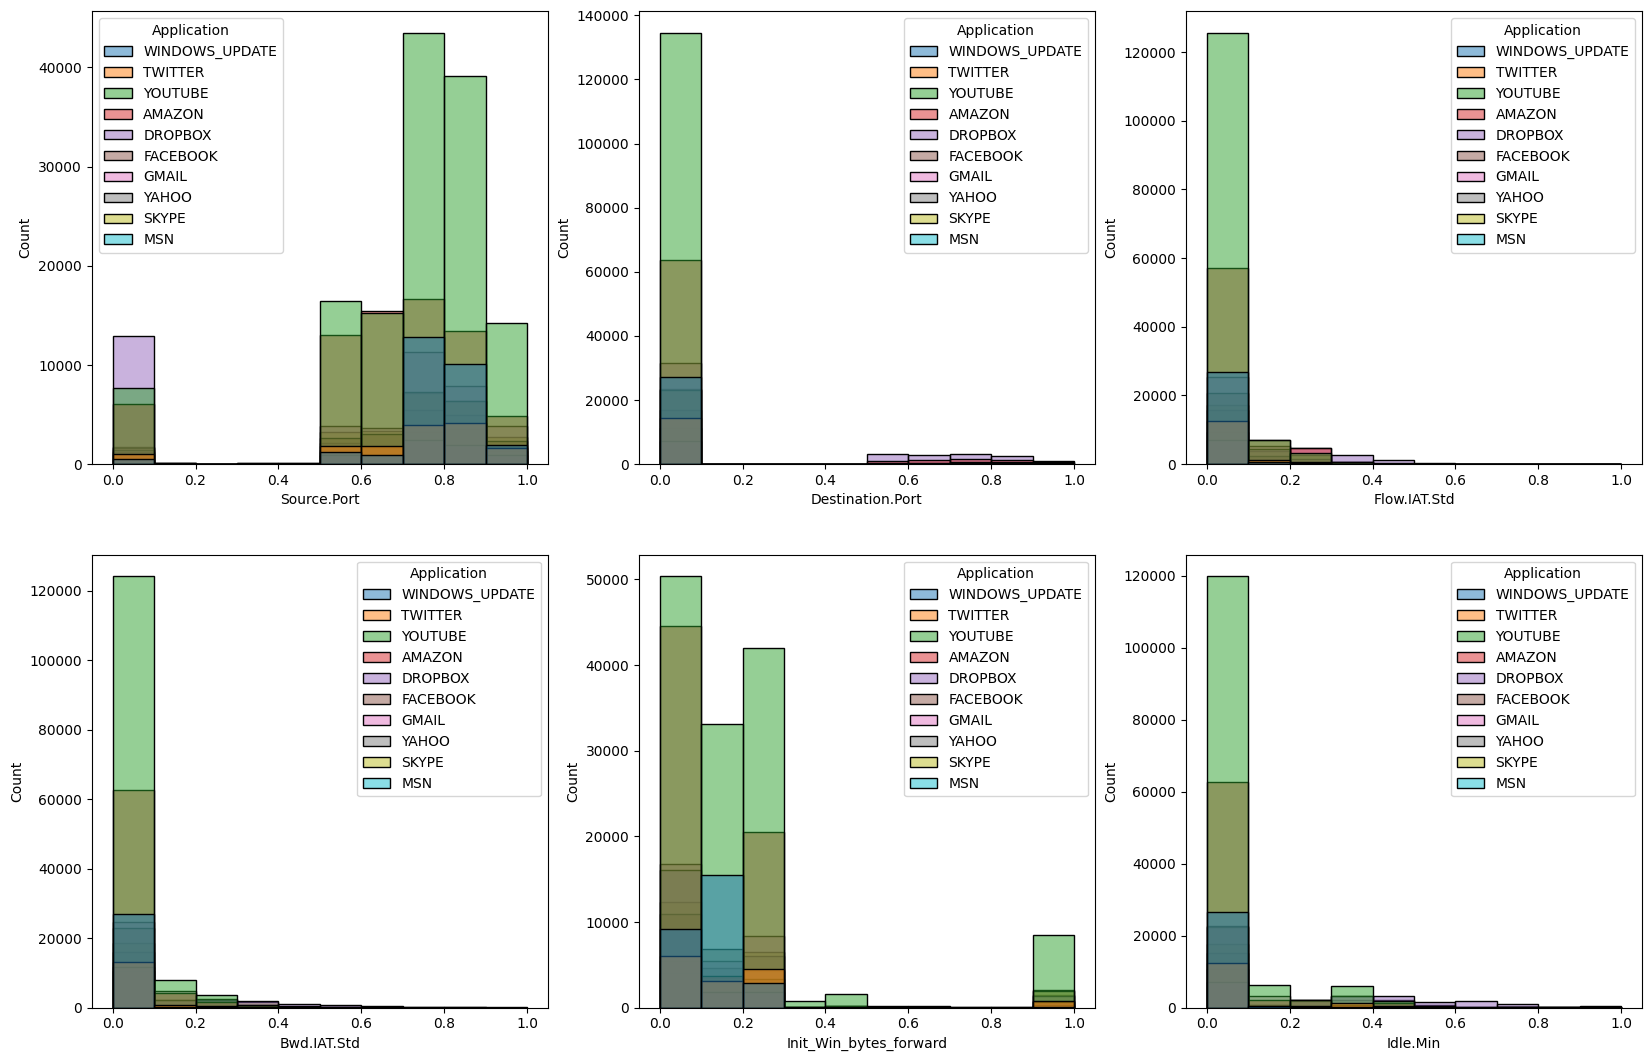

In [9]:
X_train_scaled_box_df_copy = X_train_scaled_box_df.copy()
X_train_scaled_box_df_copy['Application'] = y_train_reconstructed

plt.figure(figsize=(20, 20))
num_features = X_train_scaled_box_df.shape[1] + 1

for i, feature in enumerate(X_train_scaled_box_df.columns):
    plt.subplot(int(num_features/2), 3, i+1)
    sns.histplot(data = X_train_scaled_box_df_copy, x = f'{feature}', hue = "Application", bins = 10)

plt.show()

# 2.4 Data Visualization - PCA

[ 23.68553029  42.87143805  55.547607    65.30233728  71.73776445
  77.42817389  82.79942336  87.36199946  90.52760212  92.76805135
  94.68275181  96.17342343  97.2502646   97.78287592  98.15940753
  98.49126507  98.76755157  98.96485099  99.1419436   99.29844718
  99.44366819  99.53591995  99.62134359  99.69857477  99.770932
  99.81770996  99.85824504  99.89446867  99.92636843  99.9510478
  99.96486963  99.97704733  99.98803917  99.99297609  99.996239
  99.99808741  99.99907469  99.99971612 100.         100.        ]


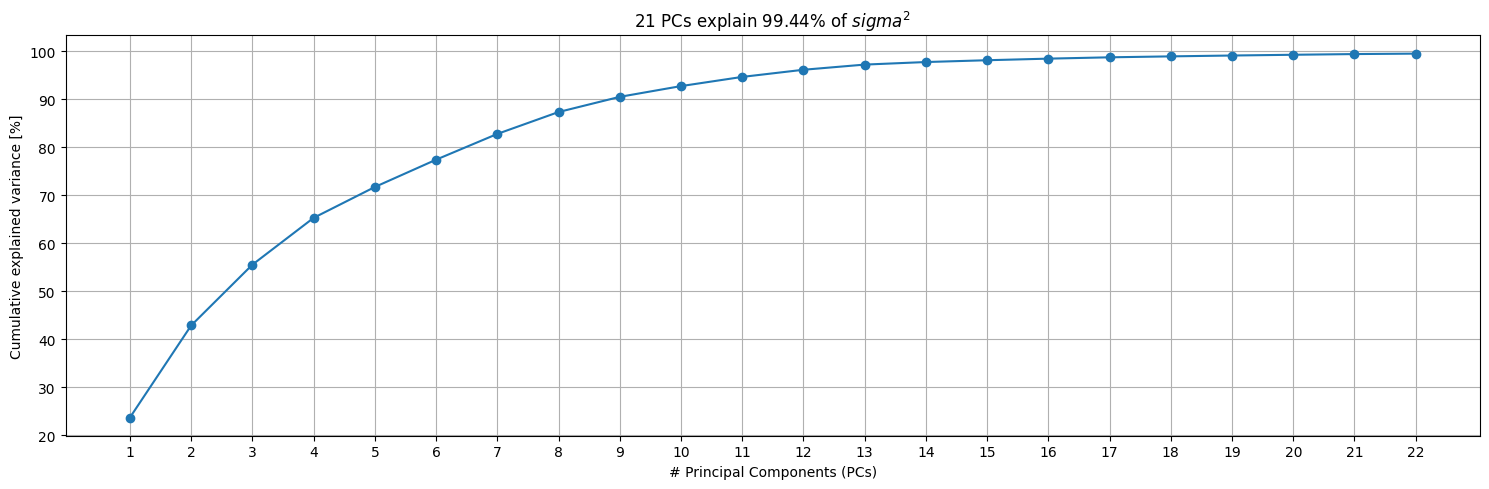

In [10]:
from sklearn.decomposition import PCA
import numpy as np

# PCA must be initialized with a random state to initialize the space
pca = PCA(random_state=15)

# .fit() is used to compute the new dimensions with number of features from 1 to the number of original features
pca.fit(X_train_scaled_df[X_train_scaled_df.columns])

# describe how much of the dataset variability is indicated by a given amount of features
explained_variance = pca.explained_variance_ratio_

# evaluate the total dataset variability while increasing the variables
cumul_exp_var = np.cumsum(explained_variance)

# percentage value to better understand the best number of components
perc_cumul_exp_var = cumul_exp_var * 100  

# make the plot of cumulative explained variance wrt number of components
plt.figure(figsize=(15, 5))
plt.plot(perc_cumul_exp_var[:22], marker='o')
print(perc_cumul_exp_var)
plt.xlabel('# Principal Components (PCs)')
plt.ylabel('Cumulative explained variance [%]')
plt.xticks([i for i in range(22)], [i for i in range(1,23)])
plt.grid()
plt.title(f'21 PCs explain {round(perc_cumul_exp_var[20], 2)}% of $sigma^2$')
plt.tight_layout()
plt.show()

In [11]:
# initialize the PCA with an appropriate number of components
pca = PCA(n_components=21, random_state=15)

# fit the data to new space
pca.fit(X_train_scaled_df[X_train_scaled_df.columns])

# transform the original data into PCA components
pca_result = pca.transform(X_train_scaled_df[X_train_scaled_df.columns])

# create the new dataset
X_train_scaled_df_pca = pd.DataFrame(pca_result, columns=[f'column {x}' for x in range(1, 22)] )
 

## Loading Score

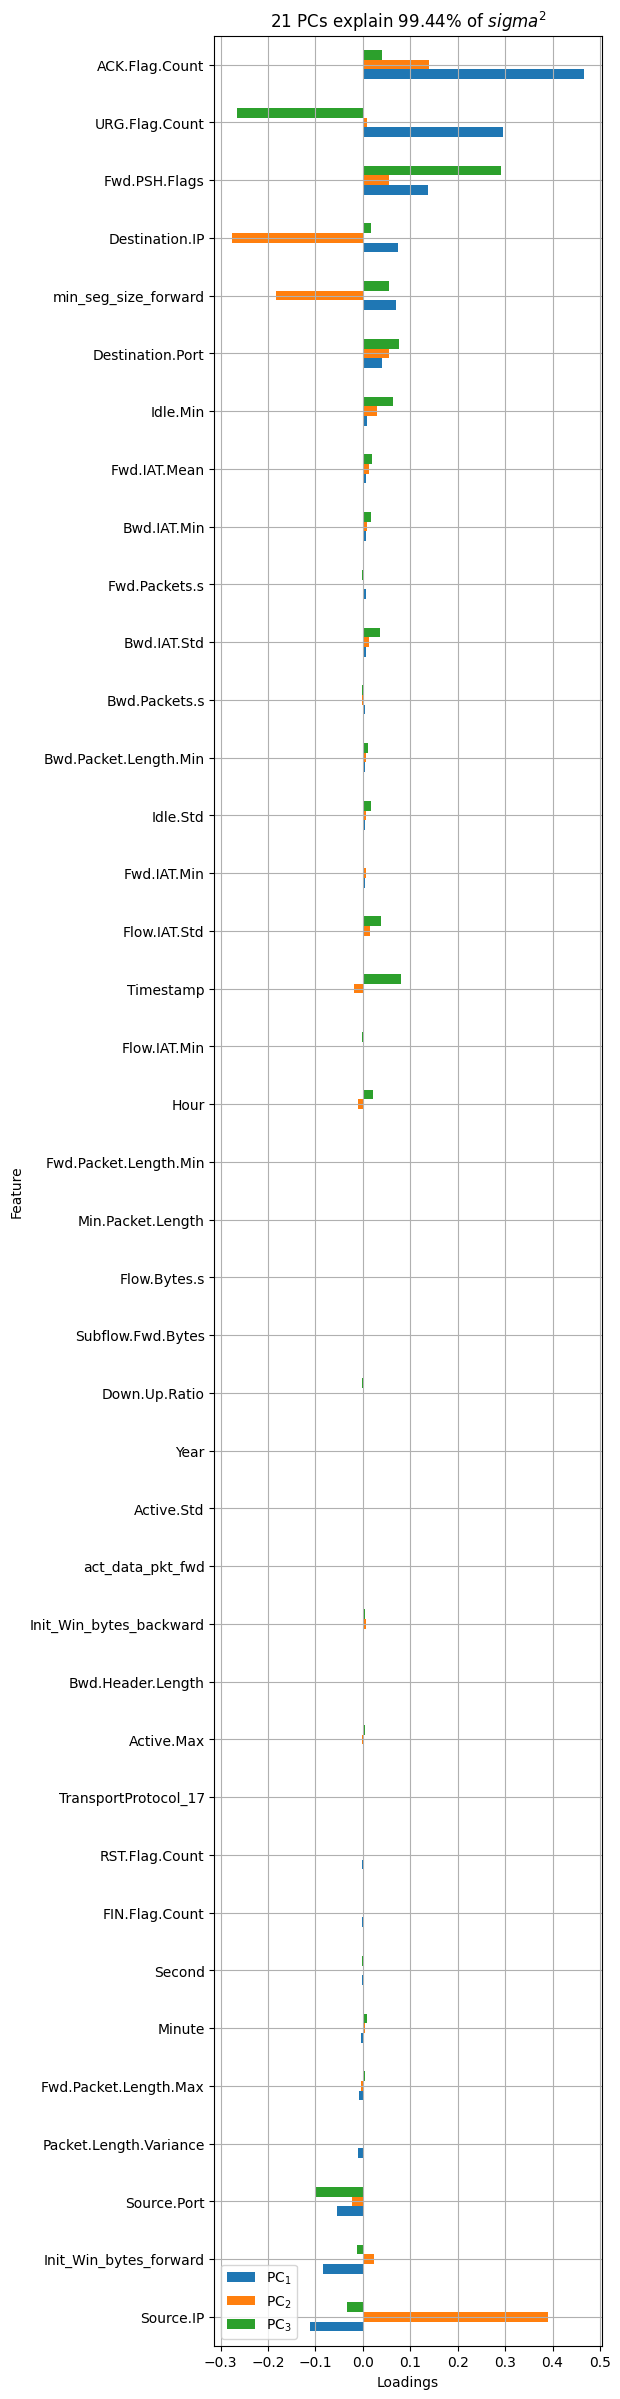

In [12]:
# Compute the loading scores and create the dataframe

loadings = pd.DataFrame(
    data = pca.components_.T * np.sqrt(pca.explained_variance_), 
    columns = [f'PC{i}' for i in range(1, 22)],
    index = X_train_scaled_df.columns
)   

plt.figure(figsize=(5, 30))
loadings = loadings[['PC1', 'PC2','PC3']]
loadings.sort_values(['PC1', 'PC2','PC3']).rename(columns={'PC1':'PC$_{1}$', 'PC2':'PC$_{2}$','PC3':'PC$_{3}$'}).plot.barh(ax=plt.gca())
plt.grid()
plt.xlabel('Loadings')
plt.ylabel('Feature')
plt.title(f'21 PCs explain {round(perc_cumul_exp_var[20], 2)}% of $ sigma^2$')
plt.show()

# Feature Reduction Using PCA Results


In [13]:
# remove features with loadings equal to zero
zero_loading_features = loadings[(loadings == 0).all(axis=1)].index
print(f"Features with loading equal to 0: {list(zero_loading_features)}")

# list of features with zero loadings
zero_loading_features_list = zero_loading_features.tolist()


X_train_scaled_df.drop(columns=zero_loading_features_list, inplace=True)
x_test_scaled_df.drop(columns= zero_loading_features_list, inplace=True)

X_train_scaled = X_train_scaled_df.to_numpy()
X_test_scaled = x_test_scaled_df.to_numpy()


print(f"Shape of the final dataframe: {X_train_scaled_df.shape}")


Features with loading equal to 0: ['Year']
Shape of the final dataframe: (376947, 39)


# 2.5 Unsupervised Data Analysis

Import needed libraries

In [14]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, rand_score, adjusted_rand_score
from sklearn.model_selection import GridSearchCV

As a first step, we remove unnecessary features and scale the whole dataset since for clustering there is no need to divide it into train, validation and test. Then, we take 10000 random samples in order to make the computation feasible.

In [15]:
X_s = scaler.fit_transform(X)
X_df = pd.DataFrame(X_s, columns=df1.drop(columns=['ProtocolName']).columns)
X_df = X_df.loc[:, columns_to_keep]
X_df = X_df.drop(columns=zero_loading_features_list)
X_s = X_df.sample(n=10000, random_state=37)
y_reconstructed = pd.DataFrame(y[X_s.index], columns=pd.get_dummies(df1['ProtocolName']).columns).idxmax(axis=1)
X_s

,Source.IP,Source.Port,Destination.IP,Destination.Port,Timestamp,Fwd.Packet.Length.Max,Fwd.Packet.Length.Min,Bwd.Packet.Length.Min,Flow.Bytes.s,Flow.IAT.Std,...,act_data_pkt_fwd,min_seg_size_forward,Active.Std,Active.Max,Idle.Std,Idle.Min,TransportProtocol_17,Hour,Minute,Second
222034,0.008706,0.866114,0.819059,0.005962,0.118835,0.000000,0.000000,0.0,0.000000e+00,0.000085,...,0.000000,0.5,0.0,0.0,0.0,0.0,0.0,0.777778,0.254237,0.169492
281880,0.008706,0.648723,0.329561,0.005962,0.689929,0.024732,0.000000,0.0,7.530376e-07,0.001941,...,0.000014,0.5,0.0,0.0,0.0,0.0,0.0,0.888889,0.508475,0.627119
345486,0.008706,0.691926,0.236395,0.000413,0.791443,0.020011,0.000000,0.0,2.976872e-07,0.002162,...,0.000009,0.5,0.0,0.0,0.0,0.0,0.0,0.777778,0.661017,0.661017
399275,0.884643,0.795926,0.031191,0.047012,0.776231,0.011879,0.000000,0.0,1.745342e-05,0.000672,...,0.000107,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.593220,0.745763
128720,0.998177,0.005956,0.031191,0.838677,0.069837,0.001675,0.012557,0.0,2.791649e-05,0.000000,...,0.000000,0.5,0.0,0.0,0.0,0.0,0.0,0.888889,0.491525,0.677966
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219875,0.008706,0.749011,0.819059,0.005962,0.118988,0.015747,0.000000,0.0,5.214262e-05,0.000063,...,0.000051,0.5,0.0,0.0,0.0,0.0,0.0,0.777778,0.322034,0.423729
437208,0.884647,0.802492,0.031191,0.047012,0.999137,0.000183,0.001370,0.0,1.485224e-10,0.000000,...,0.000005,0.0,0.0,0.0,0.0,0.0,0.0,0.888889,0.118644,0.762712
77009,0.884645,0.788000,0.031191,0.047012,0.064838,0.058601,0.000000,0.0,4.037397e-06,0.001962,...,0.000079,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.169492,0.355932
297158,0.008706,0.602083,0.286139,0.005962,0.788871,0.000000,0.000000,0.0,0.000000e+00,0.000000,...,0.000000,0.5,0.0,0.0,0.0,0.0,0.0,0.666667,0.457627,1.000000


We can visualize the clusters after reducing the feature dimensionality with a 2-component t-SNE.

In [16]:
tsne = TSNE(random_state=42)
projection = tsne.fit_transform(X_s)
projection = pd.DataFrame(projection)
projection

,0,1
0,59.964066,-0.143717
1,-57.654316,-37.020550
2,-63.145348,-32.345177
3,-24.051668,85.383415
4,24.529448,53.794514
...,...,...
9995,1.106744,-35.615490
9996,-3.195508,44.749779
9997,-37.137363,15.571190
9998,60.329521,-37.130257


### 2.5.1 K-Means

Ideal for spherical clusters and noise-free datasets. Simple and fast for well-separated data.

Find the best k using Elbow Method.

In [17]:
# Elbow Method

n_cluster_list = []
shs_list = []
inertia_list = []

for n_clusters in range(3, 26):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(X_s)
    silhouette = silhouette_score(X_s, kmeans_labels)
    shs_list.append(silhouette)
    inertia_list.append(kmeans.inertia_)
    n_cluster_list.append(n_clusters)

Plot k-Means clustering error and silhouette score.

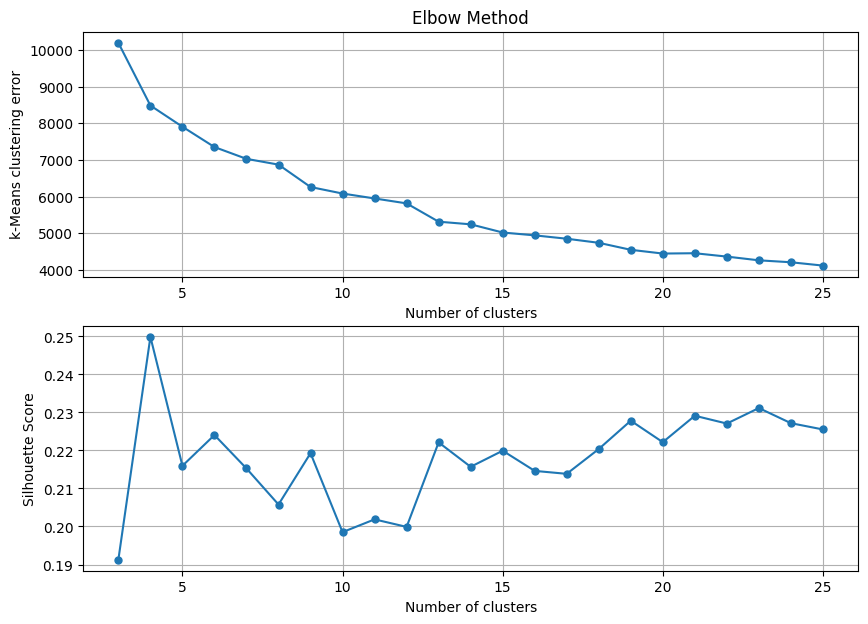

In [18]:
fig, axs = plt.subplots(2, 1, figsize=(10, 7))

axs[0].plot(n_cluster_list, inertia_list, marker='o', markersize=5)
axs[0].grid()
axs[0].set_xlabel('Number of clusters')
axs[0].set_ylabel('k-Means clustering error')
axs[0].set_title('Elbow Method')

axs[1].plot(n_cluster_list, shs_list, marker='o', markersize=5)
axs[1].grid()
axs[1].set_xlabel('Number of clusters')
axs[1].set_ylabel('Silhouette Score')
axs[1].set_title('')

plt.show()

Tuning of the other hyperparameters.

In [19]:
param_grid_kmeans = {
    'init': ['k-means++', 'random'],
    'n_init': list(range(2, 21, 2)),
    'max_iter': list(range(50, 501, 50)),
}

kmeans = KMeans(n_clusters=13, random_state=42)
grid_search_kmeans = GridSearchCV(kmeans, param_grid = param_grid_kmeans, cv=5)
grid_search_kmeans.fit(X_s)

# Get the best parameters
best_params_kmeans = grid_search_kmeans.best_params_
print("Best parameters:", best_params_kmeans)

Best parameters: {'init': 'k-means++', 'max_iter': 50, 'n_init': 18}


Execute k-Means with tuned hyperparameters and compute metrics.

In [20]:
kmeans_tuned = KMeans(n_clusters=13, init=best_params_kmeans['init'], n_init=best_params_kmeans['n_init'], max_iter=best_params_kmeans['max_iter'], random_state=42)
kmeans_tuned_labels = kmeans_tuned.fit_predict(X_s)

# Unsupervised metric
silhouette = silhouette_score(X_s, kmeans_tuned_labels)

# Supervised metrics
ri = rand_score(y_reconstructed, kmeans_tuned_labels)
ari = adjusted_rand_score(y_reconstructed, kmeans_tuned_labels)
(unique, counts) = np.unique(kmeans_tuned_labels, return_counts=True)

print('k-Means with 13 clusters')
print("Size of each cluster: ", counts)
print(f'k-Means clustering error: {round(kmeans_tuned.inertia_, 2)}')
print(f'Silhouette: {round(silhouette, 2)}')
print(f'RI: {round(ri, 2)}')
print(f'ARI: {round(ari, 2)}')

k-Means with 13 clusters
Size of each cluster:  [ 378  763 1046  796  314 1676  713  896  689  736  695  522  776]
k-Means clustering error: 5203.14
Silhouette: 0.23
RI: 0.77
ARI: 0.06


Visualize the clusters, comparing the tuned k-Means with the one with k=10 (number of labels) and the Ground Truth.

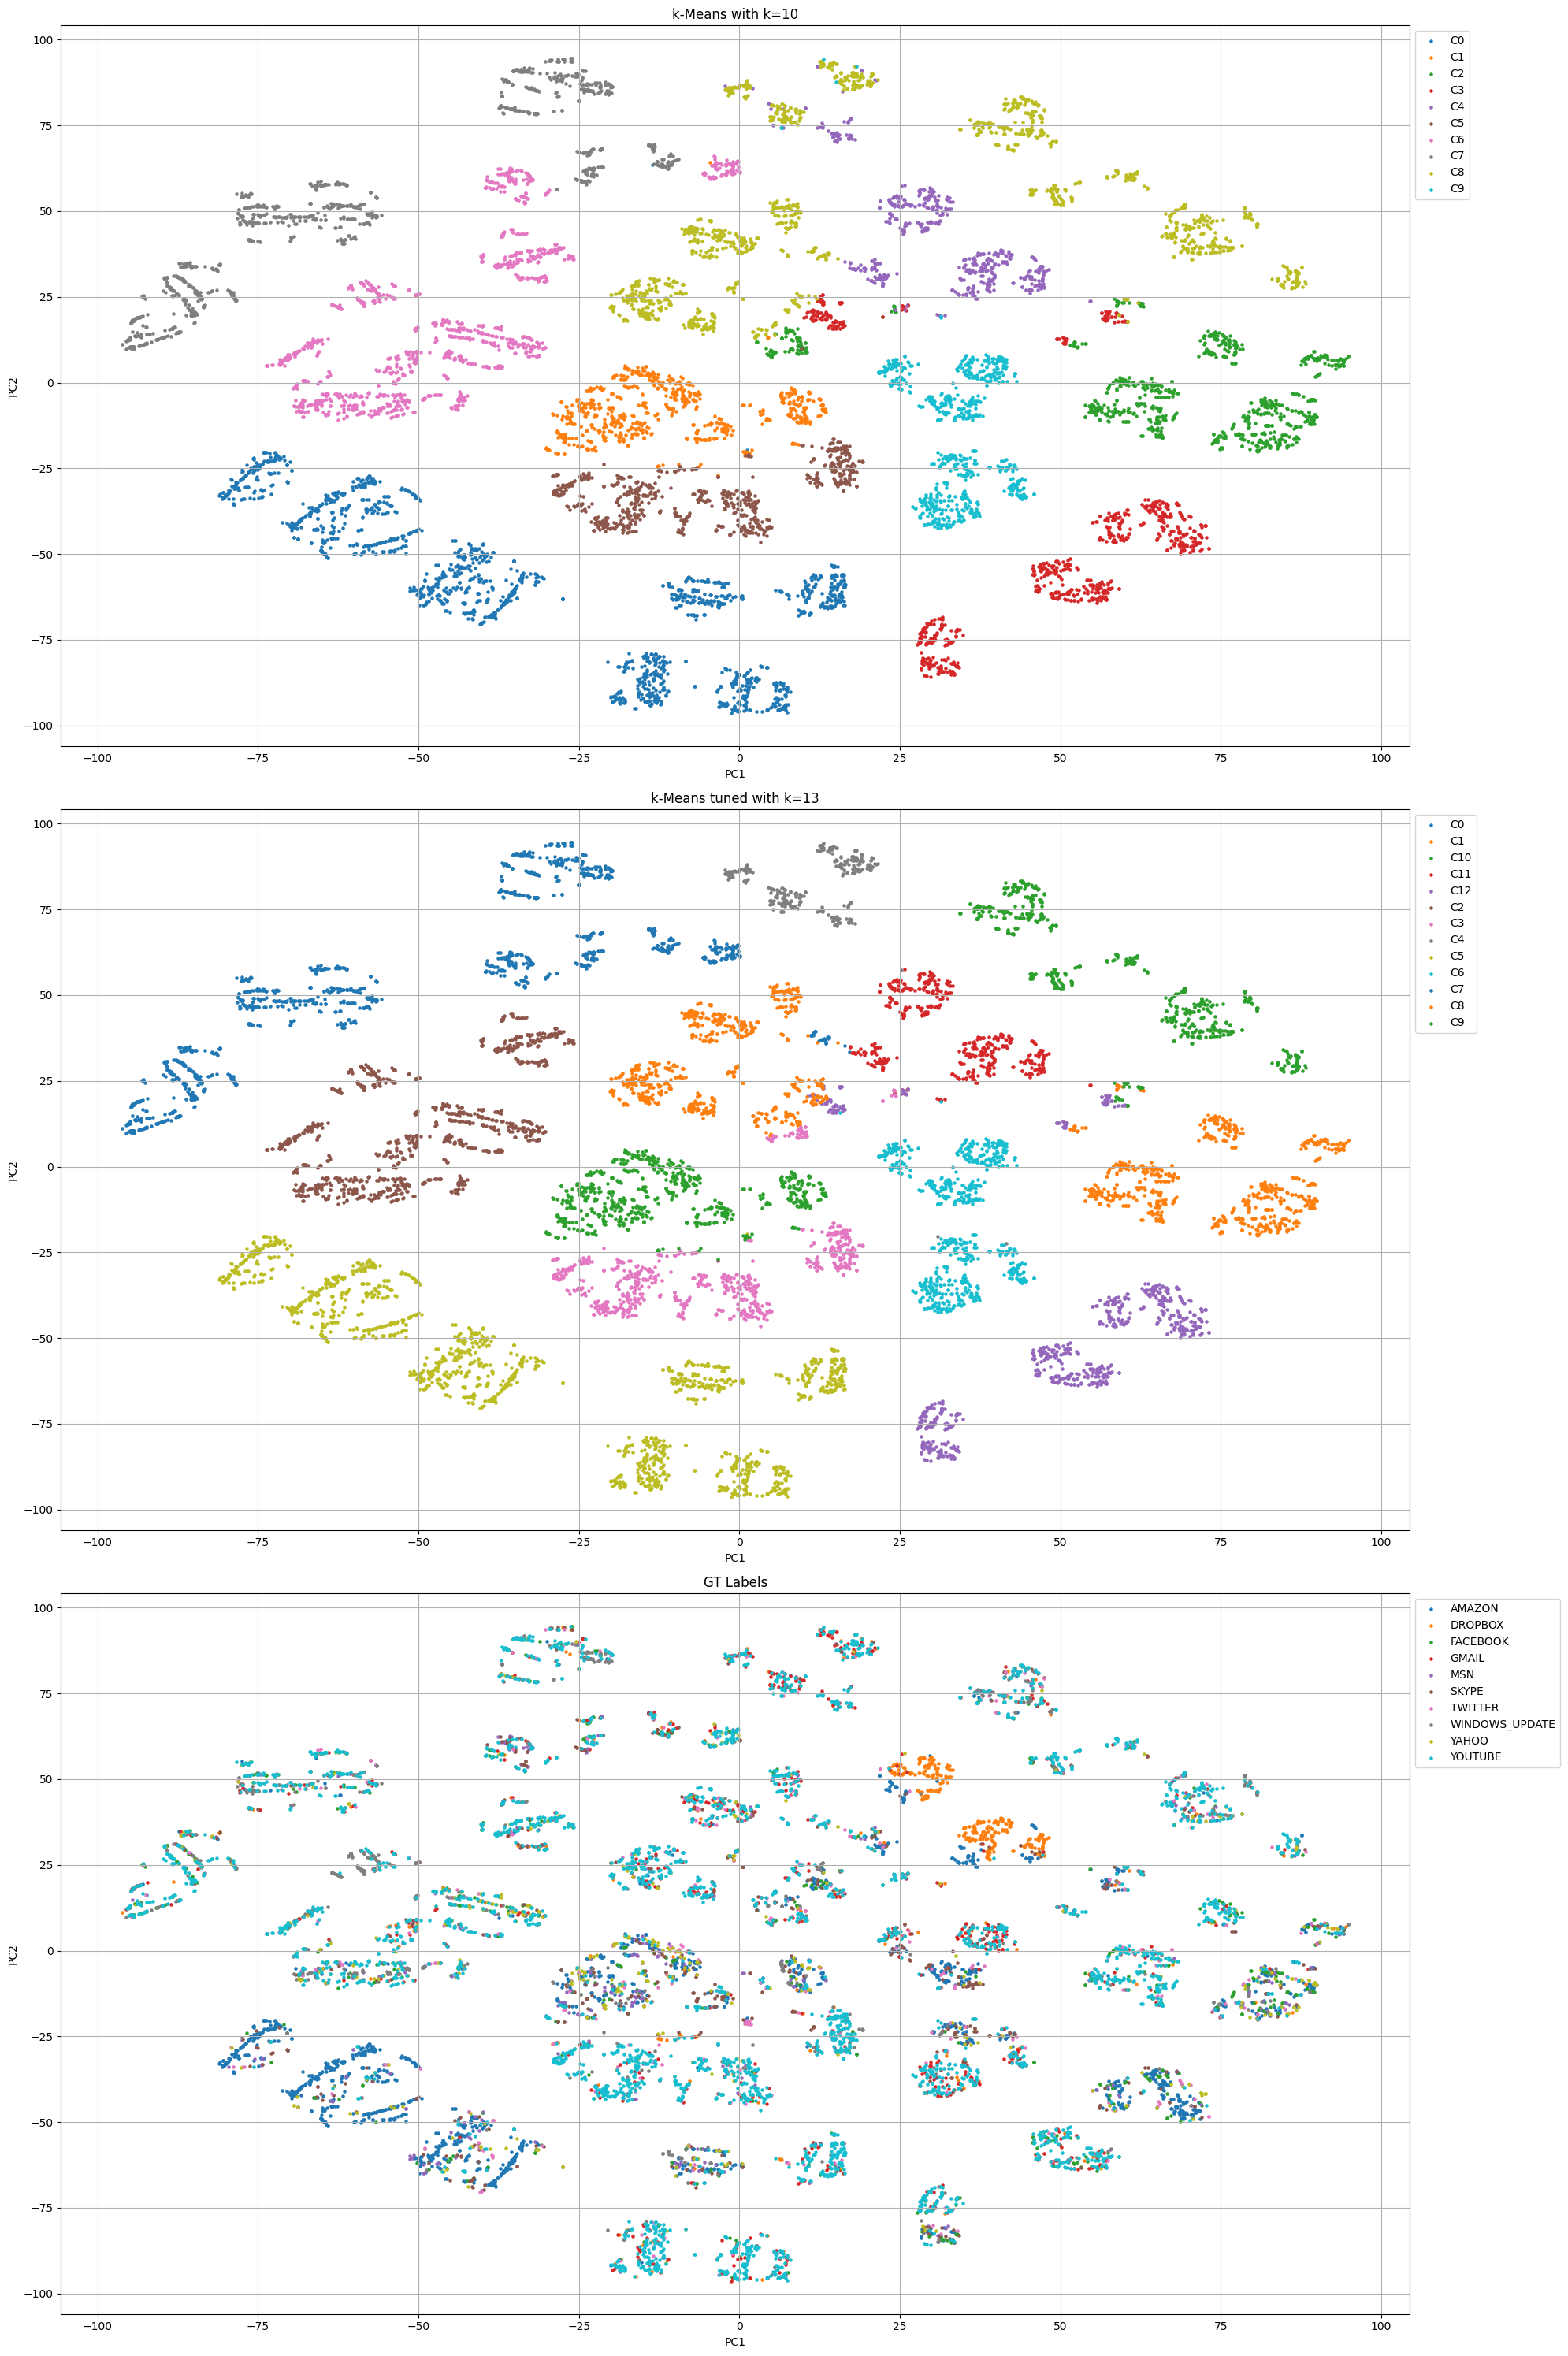

In [21]:
# Running k-Means with k=10 (i.e. the number of labels) to compare it with the tuned k-Means.
kmeans10 = KMeans(n_clusters=10, random_state=42)
kmeans_labels10 = kmeans10.fit_predict(X_s)

projection['cid10'] = [f'C{x}' for x in kmeans_labels10]
projection['cidTuned'] = [f'C{x}' for x in kmeans_tuned_labels]
projection['label'] = y_reconstructed

fig, axs = plt.subplots(3, 1, figsize=(20, 30))

for i in np.unique(projection.cid10):
    subdf = projection[projection.cid10 == i]
    axs[0].scatter(subdf[0], subdf[1], label=i, s=5)
axs[0].grid()
lgnd = axs[0].legend(bbox_to_anchor=(1, 1), loc="upper left")
axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')
axs[0].set_title('k-Means with k=10')
    
for i in np.unique(projection.cidTuned):
    subdf = projection[projection.cidTuned == i]
    axs[1].scatter(subdf[0], subdf[1], label=i, s=5)
axs[1].grid()
lgnd = axs[1].legend(bbox_to_anchor=(1, 1), loc="upper left")
axs[1].set_xlabel('PC1')
axs[1].set_ylabel('PC2')
axs[1].set_title('k-Means tuned with k=13')

for i in np.unique(projection.label):
    subdf = projection[projection.label == i]
    axs[2].scatter(subdf[0], subdf[1], label=i, s=5)
axs[2].grid()
lgnd = axs[2].legend(bbox_to_anchor=(1, 1), loc="upper left")
axs[2].set_xlabel('PC1')
axs[2].set_ylabel('PC2')
axs[2].set_title('GT Labels')

plt.tight_layout()
plt.show()

### 2.5.2 GMM (Gaussian Mixture Model)

Useful when clusters have nonspherical shapes or overlaps. Allows for probabilistic modeling.

Find the best k using Elbow Method.

In [22]:
n_cluster_list=[]
silhouette_list_gmm= []
log_l_list=[]

for n_clusters in range(3, 26):
    gmm = GaussianMixture(n_components = n_clusters, random_state=42)
    gmm_label = gmm.fit_predict(X_s)
      
    silhouette = silhouette_score(X_s, gmm_label)
    silhouette_list_gmm.append(silhouette)
    
    log_l_list.append(gmm.score(X_s))
    n_cluster_list.append(n_clusters)

Plot GMM total log-likelihood score and silhouette score.

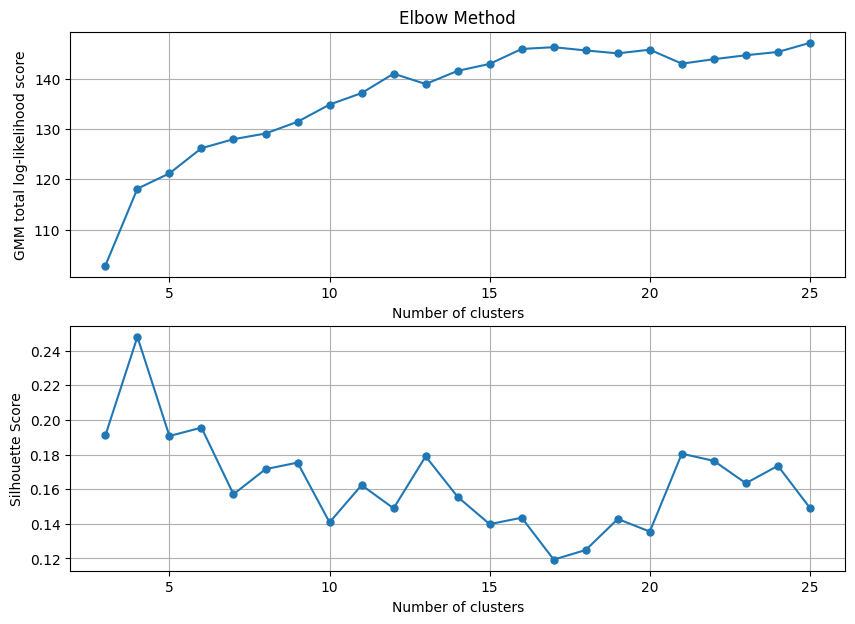

In [23]:
fig, axs = plt.subplots(2, 1, figsize=(10, 7))

axs[0].plot(n_cluster_list, log_l_list, marker='o', markersize=5)
axs[0].grid()
axs[0].set_xlabel('Number of clusters')
axs[0].set_ylabel('GMM total log-likelihood score')
axs[0].set_title('Elbow Method')

plt.plot(n_cluster_list, silhouette_list_gmm, marker='o', markersize=5)
axs[1].grid()
axs[1].set_xlabel('Number of clusters')
axs[1].set_ylabel('Silhouette Score')
axs[1].set_title('')

plt.show()

Tuning of the other hyperparameters.

In [24]:
def silhouette_scorer(gmm, X):
    labels = gmm.fit_predict(X)
    return silhouette_score(X, labels)

param_grid_gmm = {
    'init_params': ['kmeans'],
    'covariance_type': ['full', 'tied', 'diag', 'spherical'],
    'tol': [1e-3, 1e-4, 1e-5],
    'max_iter': list(range(50, 300, 50)),
}

gmm = GaussianMixture(n_components=13, random_state=42)
grid_search_gmm = GridSearchCV(gmm, param_grid_gmm, cv=5, scoring = silhouette_scorer)
grid_search_gmm.fit(X_s)

# Get the best parameters
best_params_gmm = grid_search_gmm.best_params_
print("Best parameters:", best_params_gmm)

c:\Users\calog\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
c:\Users\calog\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
c:\Users\calog\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
c:\Users\calog\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. T

Best parameters: {'covariance_type': 'spherical', 'init_params': 'kmeans', 'max_iter': 50, 'tol': 0.001}


Execute GMM with tuned hyperparameters and compute metrics.

In [25]:
gmm_tuned = GaussianMixture(n_components=13, random_state=42, init_params=best_params_gmm['init_params'], covariance_type=best_params_gmm['covariance_type'], max_iter=best_params_gmm['max_iter'], tol=best_params_gmm['tol'])
gmm_tuned_labels = gmm_tuned.fit_predict(X_s)

# Unsupervised metrics
silhouette = silhouette_score(X_s, gmm_tuned_labels)
log_l_tuned = gmm_tuned.score(X_s)

# Supervised metrics
ri = rand_score(y_reconstructed, gmm_tuned_labels)
ari = adjusted_rand_score(y_reconstructed, gmm_tuned_labels)

print('GMM with 13 clusters')
# Report effective size
print("Effective size of each cluster: ", gmm_tuned.weights_)
# Report unsupervised and supervised metrics
print(f'GMM total log-likelihood score: {round(log_l_tuned, 2)}')
print(f'Silhouette: {round(silhouette, 2)}')
print(f'RI: {round(ri, 2)}')
print(f'ARI: {round(ari, 2)}')

GMM with 13 clusters
Effective size of each cluster:  [0.06534786 0.07122225 0.10263072 0.06014352 0.04485782 0.07288353
 0.10318445 0.0886258  0.08104534 0.07097978 0.07258195 0.10066266
 0.06583431]
GMM total log-likelihood score: 27.86
Silhouette: 0.2
RI: 0.77
ARI: 0.05


Visualize the clusters, comparing the tuned GMM with the one with k=10 (number of labels) and the Ground Truth.

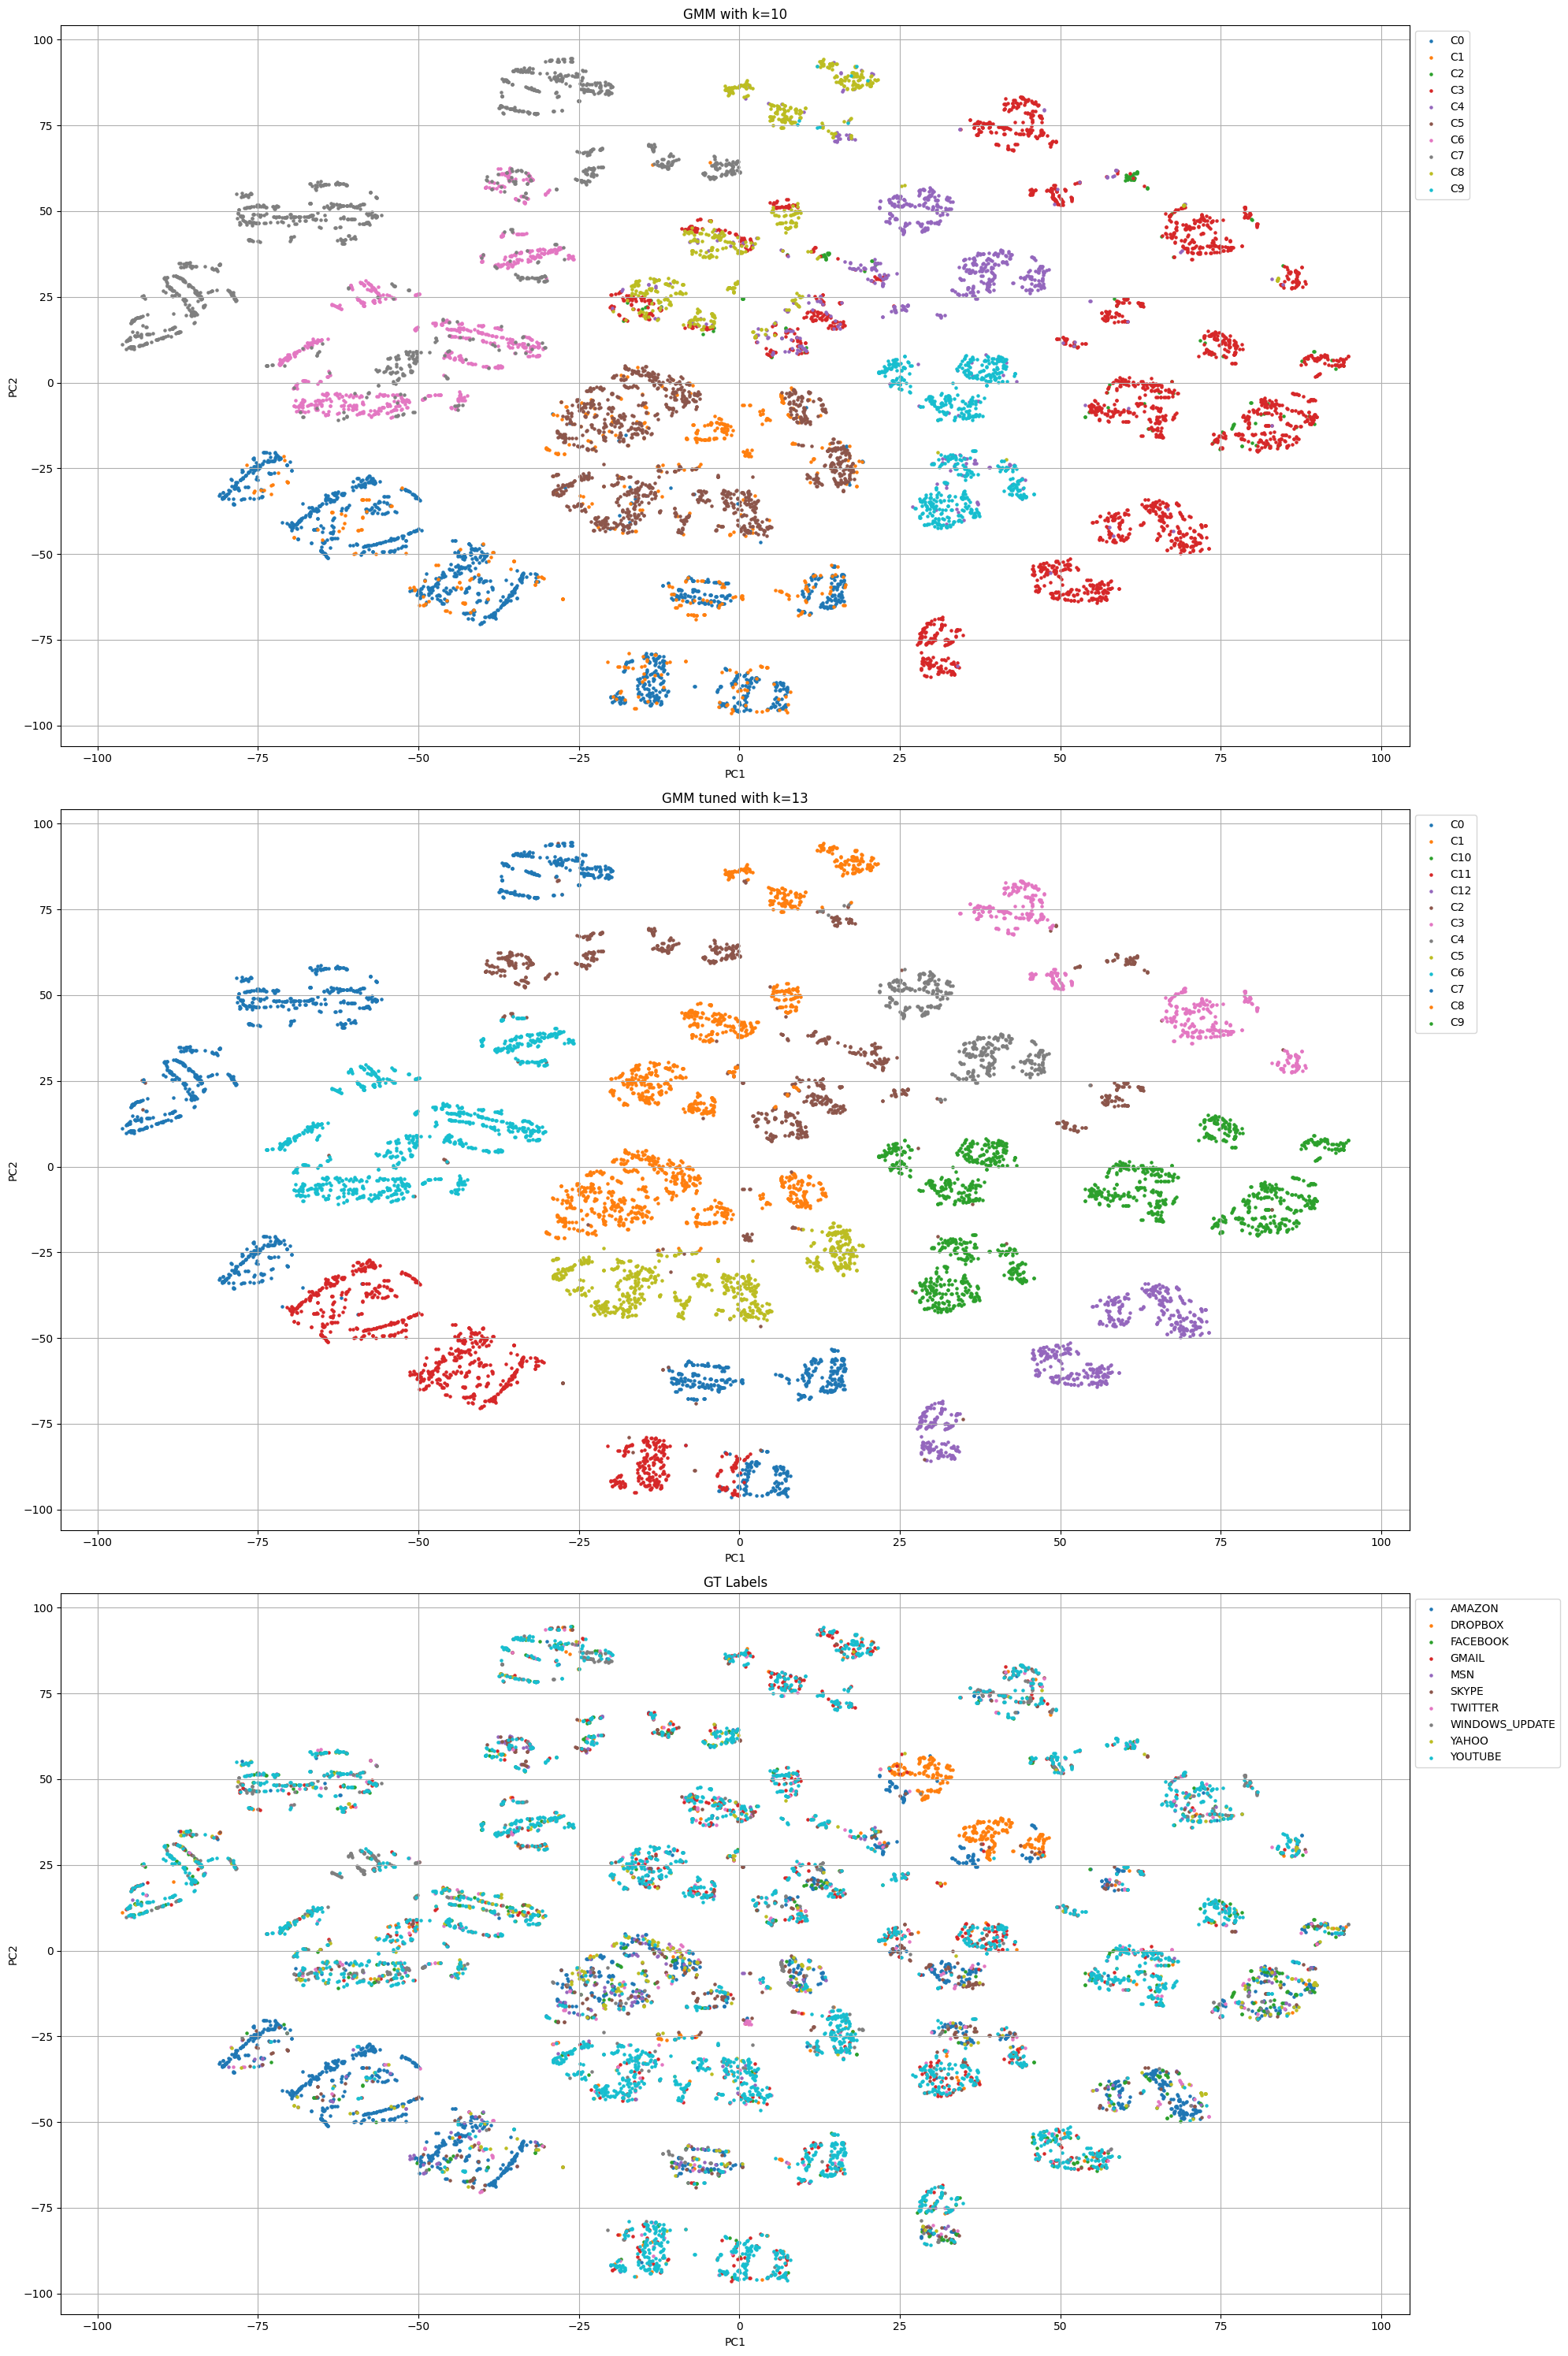

In [26]:
# Running GMM with k=10 (i.e. the number of labels) to compare it with the tuned GMM.
gmm10 = GaussianMixture(n_components=10, random_state=42)
gmm_labels10 = gmm10.fit_predict(X_s)

projection['cid10'] = [f'C{x}' for x in gmm_labels10]
projection['cidTuned'] = [f'C{x}' for x in gmm_tuned_labels]
projection['label'] = y_reconstructed

fig, axs = plt.subplots(3, 1, figsize=(20, 30))

for i in np.unique(projection.cid10):
    subdf = projection[projection.cid10 == i]
    axs[0].scatter(subdf[0], subdf[1], label=i, s=5)
axs[0].grid()
lgnd = axs[0].legend(bbox_to_anchor=(1, 1), loc="upper left")
axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')
axs[0].set_title('GMM with k=10')
    
for i in np.unique(projection.cidTuned):
    subdf = projection[projection.cidTuned == i]
    axs[1].scatter(subdf[0], subdf[1], label=i, s=5)
axs[1].grid()
lgnd = axs[1].legend(bbox_to_anchor=(1, 1), loc="upper left")
axs[1].set_xlabel('PC1')
axs[1].set_ylabel('PC2')
axs[1].set_title('GMM tuned with k=13')

for i in np.unique(projection.label):
    subdf = projection[projection.label == i]
    axs[2].scatter(subdf[0], subdf[1], label=i, s=5)
axs[2].grid()
lgnd = axs[2].legend(bbox_to_anchor=(1, 1), loc="upper left")
axs[2].set_xlabel('PC1')
axs[2].set_ylabel('PC2')
axs[2].set_title('GT Labels')

plt.tight_layout()
plt.show()

### 2.5.3. DBSCAN
Good for identifying clusters of irregular shapes and handling noise. Ideal for data with variable density.

In [27]:
dbscan = DBSCAN()
dbscan_labels = dbscan.fit_predict(X_s) # Get clusters ID

# Unsupervised metric
silhouette = silhouette_score(X_s, dbscan_labels)

# Supervised metrics
ri = rand_score(y_reconstructed, dbscan_labels)
ari = adjusted_rand_score(y_reconstructed, dbscan_labels)

# Report number and size of each cluster
(unique, counts) = np.unique(dbscan_labels, return_counts=True)
print("Number of clusters (including noise): ", len(unique))
print("Size of each cluster: ", counts)

# Report unsupervised and supervised metrics
print(f'Silhouette: {round(silhouette, 2)}')
print(f'RI: {round(ri, 2)}')
print(f'ARI: {round(ari, 2)}')

Number of clusters (including noise):  72
Size of each cluster:  [ 679  675 1633  858  125  233   46  897 1321  248   16   12    8   71
  648  314  139   60  260   74  160  152  190   69   36    8   80   21
   58   27   53  100   38   63  101   57   15   42   43   37   17   21
    5   20   15    5   33   18   14   24   17   10    7    8    8    5
    6    7   18    7    7    5    9    6    5    8   10    2    2    4
    5    5]
Silhouette: 0.11
RI: 0.77
ARI: 0.05


Now analyze the performance varying epsilon and min_samples.

In [28]:
shs = []

for eps in np.arange(0.01, 2, 0.1):
    eps = round(eps, 3)
    
    for mins in range(1, 20):
        dbscan = DBSCAN(eps=eps, min_samples=mins)
        dbscan_labels = dbscan.fit_predict(X_s)
        try:
            silhouette = silhouette_score(X_s, dbscan_labels)
        except:
            silhouette = np.nan
        shs.append((eps, mins, silhouette))

Plot the silhouette score for the different values with a heatmap.

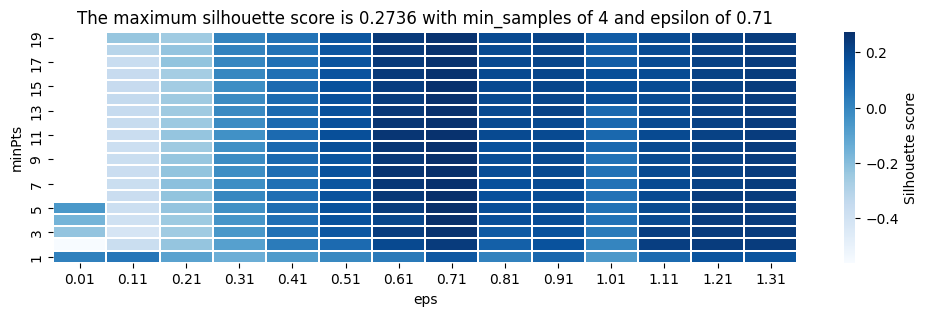

In [29]:
gs = pd.DataFrame(shs, columns=['eps', 'minPts', 'sh'])
gs = pd.pivot_table(gs, columns='eps', index='minPts', values='sh', aggfunc=lambda x:x)

plt.figure(figsize=(12,3))
max_ss = gs.max().max()
mins_max_ss = gs.stack().idxmax()[0]
eps_max_ss = gs.stack().idxmax()[1]
plt.title(f'The maximum silhouette score is {round(max_ss,4)} with min_samples of {mins_max_ss} and epsilon of {eps_max_ss}')
sns.heatmap(gs, cmap='Blues', cbar_kws={'label':'Silhouette score'}, linewidths=.005)
plt.gca().invert_yaxis()
plt.show()

Report the results of the best combination, for all metrics.

In [30]:
dbscan = DBSCAN(eps=eps_max_ss, min_samples=mins_max_ss)
dbscan_labels = dbscan.fit_predict(X_s) # Get clusters ID

# Unsupervised metric
silhouette = silhouette_score(X_s, dbscan_labels)

# Supervised metrics
ri = rand_score(y_reconstructed, dbscan_labels)
ari = adjusted_rand_score(y_reconstructed, dbscan_labels)

# Report number and size of each cluster
(unique, counts) = np.unique(dbscan_labels, return_counts=True)
print("Number of clusters (including noise): ", len(unique))
print("Size of each cluster: ", counts)

# Report unsupervised and supervised metrics
print(f'Silhouette: {round(silhouette, 2)}')
print(f'RI: {round(ri, 2)}')
print(f'ARI: {round(ari, 2)}')

Number of clusters (including noise):  21
Size of each cluster:  [ 114 1385 3123 2277  427  520   64  280  706  230   81  618   42   33
   12   26   20    6   19   12    5]
Silhouette: 0.27
RI: 0.71
ARI: 0.05


Visualize the clusters.

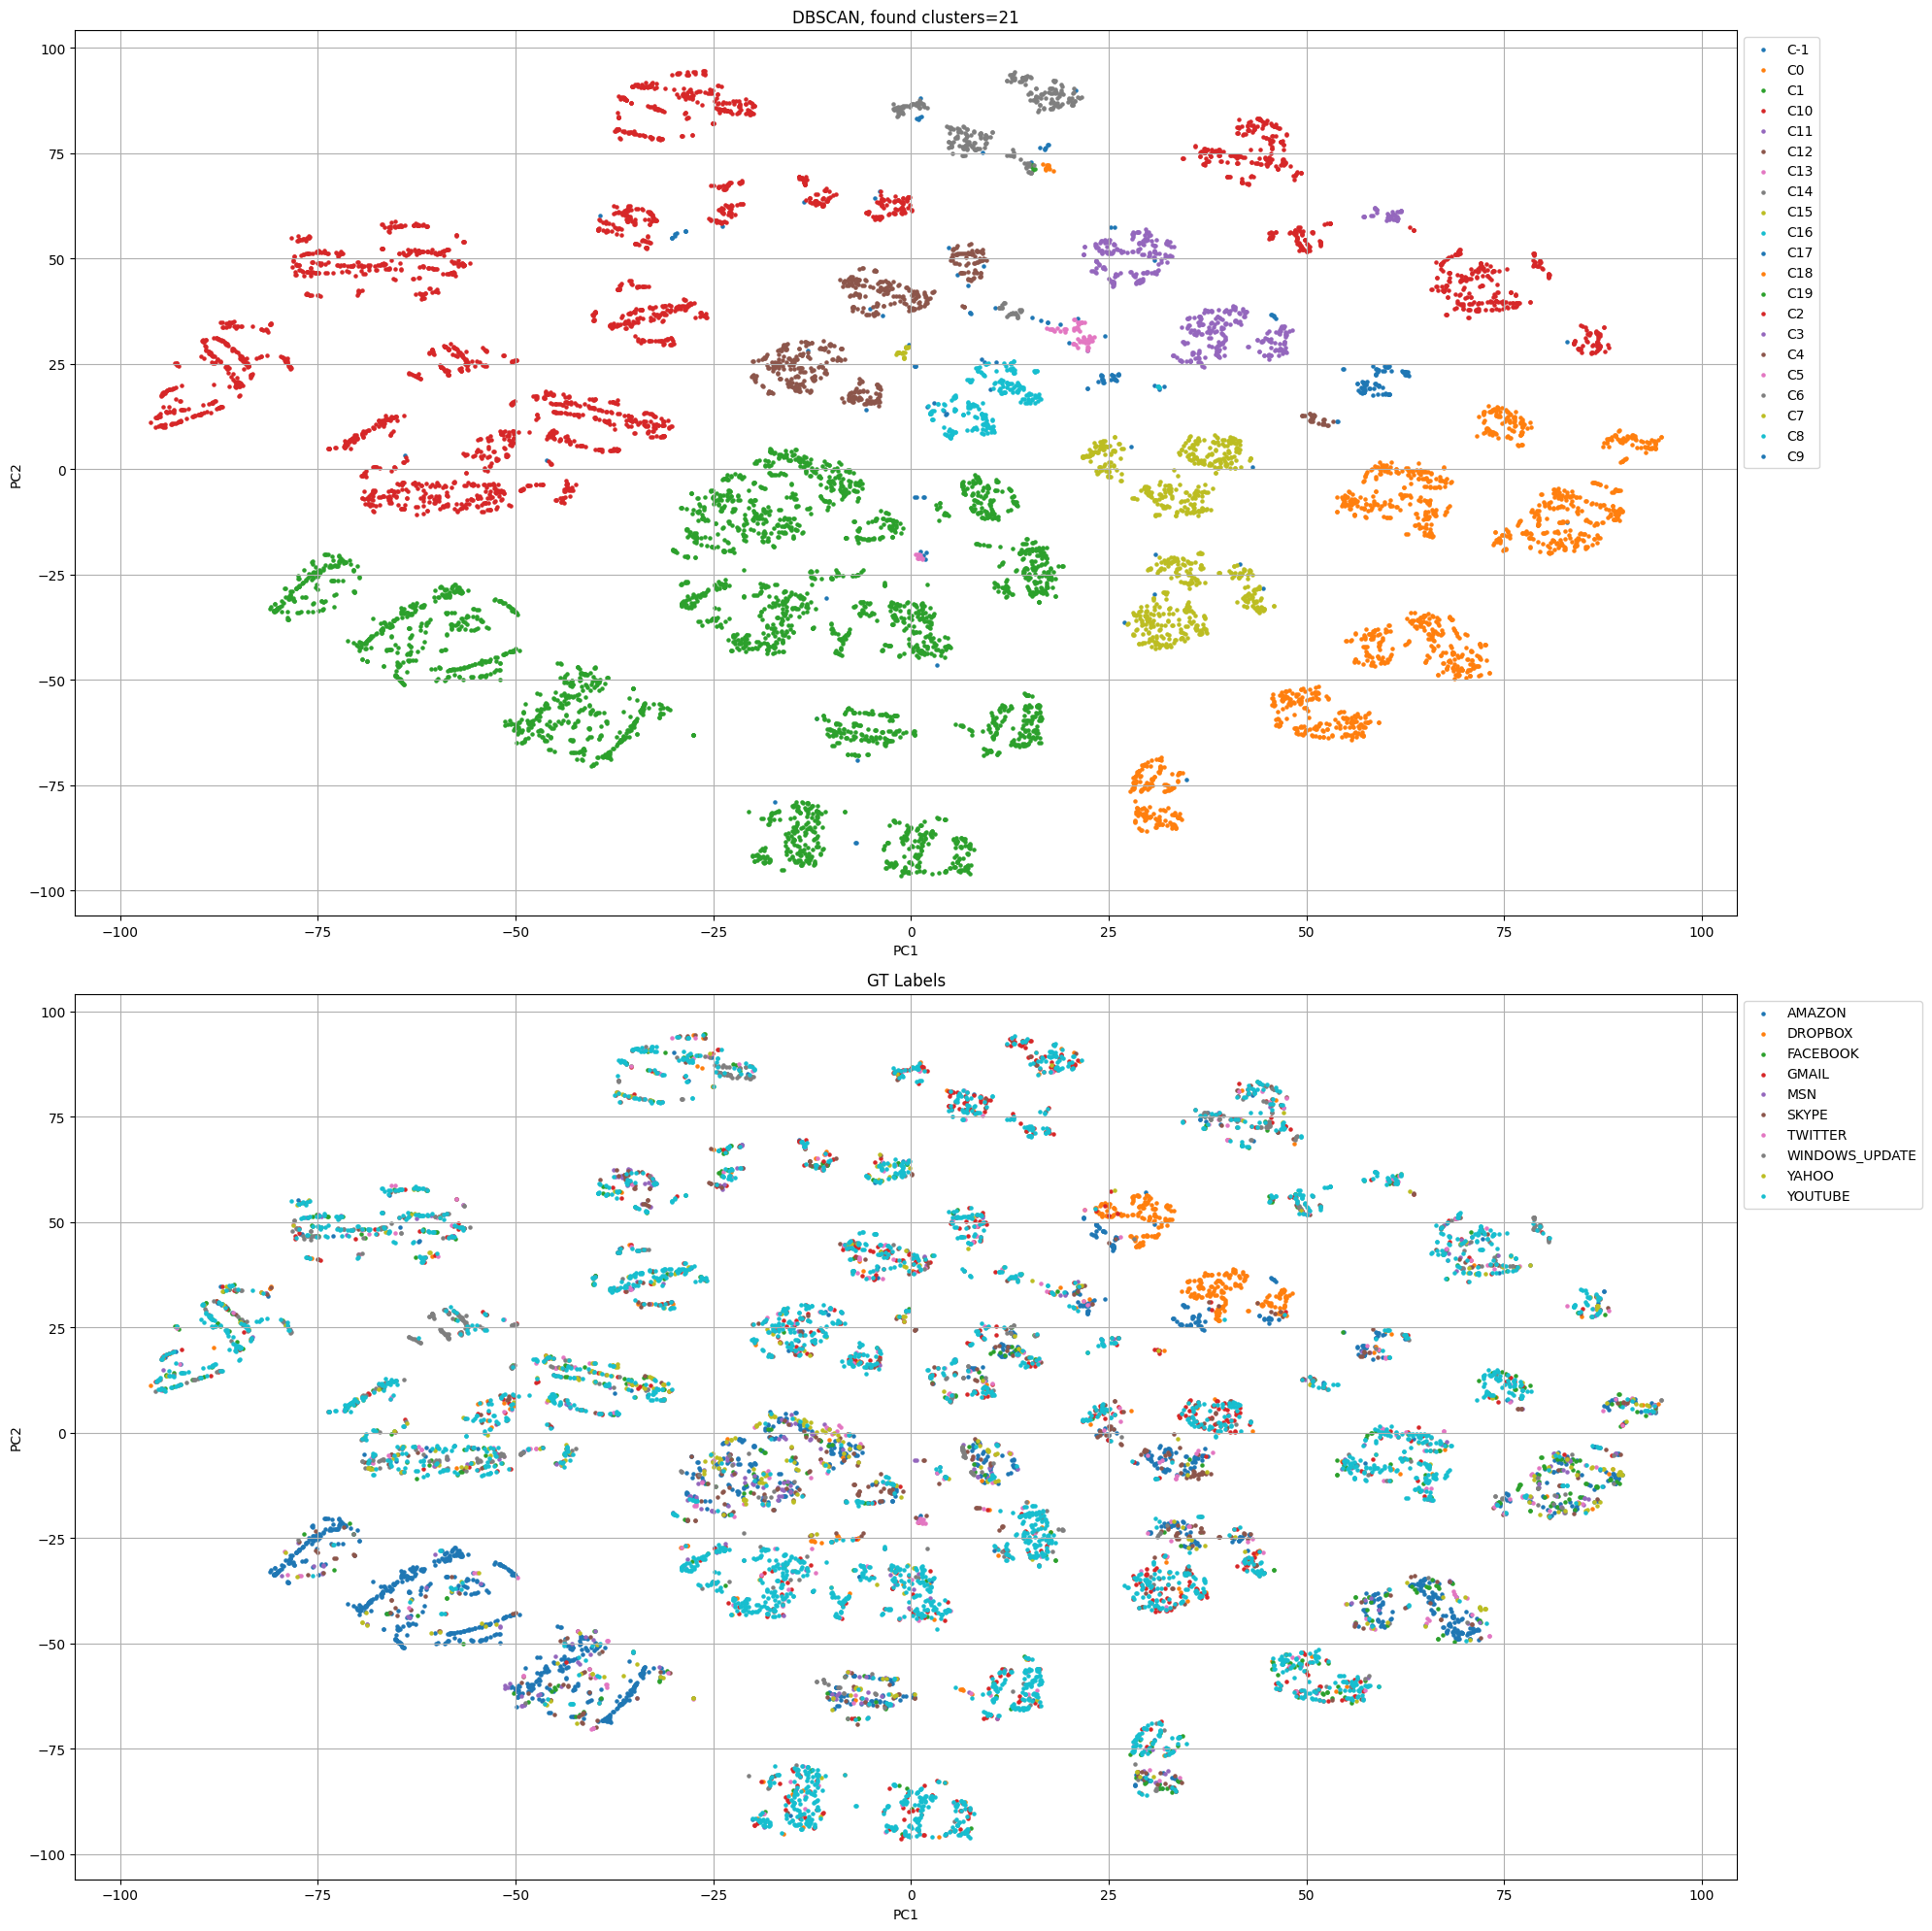

In [31]:
projection['cidBest'] = [f'C{x}' for x in dbscan_labels]
projection['label'] = y_reconstructed

fig, axs = plt.subplots(2, 1, figsize=(20, 20))

for i in np.unique(projection.cidBest):
    subdf = projection[projection.cidBest == i]
    axs[0].scatter(subdf[0], subdf[1], label=i, s=5)
axs[0].grid()
lgnd = axs[0].legend(bbox_to_anchor=(1, 1), loc="upper left")
axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')
axs[0].set_title(f'DBSCAN, found clusters={len(unique)}')

for i in np.unique(projection.label):
    subdf = projection[projection.label == i]
    axs[1].scatter(subdf[0], subdf[1], label=i, s=5)
axs[1].grid()
lgnd = axs[1].legend(bbox_to_anchor=(1, 1), loc="upper left")
axs[1].set_xlabel('PC1')
axs[1].set_ylabel('PC2')
axs[1].set_title('GT Labels')

plt.tight_layout()
plt.show()

# 3. Supervised Data Analysis

###   Random Forest Classifier

For the Random Forest Classifier we are evaluating throught a validation curve the best max_depth hyperparameter value.

The model validation has been performed with k-fold cross-validation. Specifically we used 5 folds for each iteration.

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

acc_train_means = []
acc_train_maxs = []     
acc_train_mins = []
acc_val_means = []
acc_val_maxs = []
acc_val_mins = []

for n in range(15,20):
    rf_clf = RandomForestClassifier(max_depth=n, n_jobs=-1)
    scores = cross_validate(rf_clf, X_train_scaled, y_train, cv=5, scoring='accuracy', return_train_score=True)
    acc_train_means.append(scores['train_score'].mean())
    acc_train_maxs.append(scores['train_score'].max())
    acc_train_mins.append(scores['train_score'].min())
    acc_val_means.append(scores['test_score'].mean())
    acc_val_maxs.append(scores['test_score'].max())
    acc_val_mins.append(scores['test_score'].min())

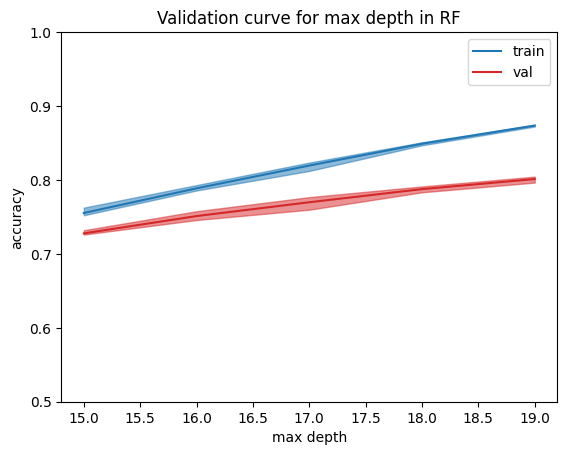

In [33]:
plt.figure()
x = list(range(15, 20))
plt.plot(x, acc_train_means, color='tab:blue', label='train')
plt.fill_between(x, acc_train_mins, acc_train_maxs, alpha=0.5, color='tab:blue')
plt.plot(x, acc_val_means, color='tab:red', label='val')
plt.fill_between(x, acc_val_mins, acc_val_maxs, alpha=0.5, color='tab:red')
plt.xlabel('max depth')
plt.ylabel('accuracy')
plt.legend()
plt.title("Validation curve for max depth in RF")
plt.ylim(0.5,1)
plt.show()

In [34]:

print('Training accuracy for max_depth=18: ', round(acc_train_means[3],4))
print('Validation accuracy for max_depth=18: ', round(acc_val_means[3],4))

Training accuracy for max_depth=18:  0.849
Validation accuracy for max_depth=18:  0.7876


### Neural Networks

In [35]:
# import needed python libraries and defining useful functions
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F


# define the function that calculate the accuracy
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # .item() to convert a tensor into a primitive type (float or int).
    acc = (correct / len(y_pred))
    return acc

# function to compute and plot the confusion matrix
def confusion_matrix(y_true, y_pred):
    df = pd.DataFrame([x for x in zip([x.item() for x in y_true], [x.item() for x in y_pred])], columns=['y_true', 'y_pred'])
    df[['samples']] = 1
    confusion = pd.pivot_table(df, index='y_true', columns='y_pred', values='samples', aggfunc=sum)
    plt.figure()
    sns.heatmap(confusion, cmap='Blues', annot=True, cbar_kws={'label':'Occurrences'}, fmt='g')
    plt.xlabel('Prediction')
    plt.ylabel('True')    
    plt.title('Confusion matrix')
    plt.show()

def create_batches(data, labels, batch_size):
    num_samples = data.shape[0]
    batches = []
    for i in range(0, num_samples, batch_size):
        data_batch = data[i:i + batch_size]
        label_batch = labels[i:i + batch_size]
        batches.append((data_batch, label_batch))
    return batches

In [36]:
# reconstruction of y in single numerical value
y_train_reconstructed = pd.DataFrame(y_train, columns=pd.get_dummies(df1['ProtocolName']).columns).idxmax(axis=1)
y_train_reconstructed_numeric = pd.Categorical(y_train_reconstructed).codes

# splitting data for validation
X_train_1, X_val, y_train_1, y_val = train_test_split(
    X_train_scaled_df, 
    y_train_reconstructed_numeric,
    train_size=0.8, random_state=7)

# transforming in tensor to use NN
X_train_t = torch.tensor(X_train_1.to_numpy(), dtype=torch.float32)
y_train_t = torch.tensor(y_train_1, dtype=torch.long)
X_val_t = torch.tensor(X_val.to_numpy(), dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)


# test tensor
y_test_reconstructed = pd.DataFrame(y_test, columns=pd.get_dummies(df1['ProtocolName']).columns).idxmax(axis=1)
y_test_reconstructed_numeric = pd.Categorical(y_test_reconstructed).codes
X_test_t = torch.tensor(x_test_scaled_df.values, dtype=torch.float)  
y_test_t = torch.tensor(y_test_reconstructed_numeric, dtype=torch.long)

In [37]:
class Model_classification_multi(nn.Module): 

    def __init__(self, in_features, out_features, hidden_1, hidden_2):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=hidden_1),
            nn.Tanh(),
            nn.Linear(in_features=hidden_1, out_features=hidden_2),
            nn.Tanh(),
            nn.Linear(in_features=hidden_2, out_features=out_features), 
        )

    # feedforward process
    def forward(self, x):
        return self.layers(x)

torch.manual_seed(8)    # random seed 

In [38]:
# cross-validation
from sklearn.model_selection import KFold
import torch.nn.functional as F
import numpy as np

# Number of folds for cross-validation
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Hyperparameters
batch_size = 64 
learning_rate = 1e-3
num_epochs = 10


# To store results
fold_accuracies = []

# K-Fold Cross-Validation
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_t)):
    current_max_acc = 0
    print(f"\n--- Fold {fold+1}/{k_folds} ---")

    # Split the data for the current fold
    X_train_fold, X_val_fold = X_train_t[train_idx], X_train_t[val_idx]
    y_train_fold, y_val_fold = y_train_t[train_idx], y_train_t[val_idx]

    # Create batches
    batches = list(create_batches(X_train_fold, y_train_fold, batch_size))

    # Initialize the model
    model = Model_classification_multi(
        in_features = X_train_t.shape[-1], 
        out_features = np.unique(y_train_t).shape[0], 
        hidden_1 = 64, 
        hidden_2 = 32,
    )

    # Loss function and optimizer
    class_counts = torch.bincount(y_train_t)
    class_weights = 1.0 / class_counts.float()
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)

    # Training for the current fold
    for epoch in range(num_epochs):
        model.train()
        loss_all = []
        for _, (data_batch, label_batch) in enumerate(batches):
            y_prob = model(data_batch).squeeze()  # Model predictions
            loss_batch = loss_fn(y_prob, label_batch)  # Compute loss
            loss_all.append(loss_batch.item())
            optimizer.zero_grad()  # Reset gradients
            loss_batch.backward()  # Backpropagation
            optimizer.step()  # Update model parameters

        # Evaluation for the current fold
        model.eval()
        with torch.no_grad():
            # Training set evaluation
            y_prob_train = model(X_train_fold).squeeze()
            y_pred_train = torch.argmax(y_prob_train, dim=-1)
            acc_train = accuracy_fn(y_train_fold, y_pred_train)

            # Validation set evaluation
            y_prob_val = model(X_val_fold).squeeze()
            loss_val = loss_fn(y_prob_val, y_val_fold)
            y_pred_val = torch.argmax(y_prob_val, dim=-1)
            acc_val = accuracy_fn(y_val_fold, y_pred_val)

        # Print metrics
        print(f"Epoch: {epoch} | Train Loss: {np.mean(loss_all):.5f}, Val Loss: {loss_val:.5f}, "
              f"Train Acc: {acc_train:.2f}, Val Acc: {acc_val:.2f}")

        # Update maximum accuracy
        if acc_val > current_max_acc:
            current_max_acc = acc_val
        else:
            break  # Early stopping

    # Store accuracy for the current fold
    fold_accuracies.append(current_max_acc)

# Average accuracy across all folds
print(f"\nCross-Validation Results: {np.mean(fold_accuracies):.2f} ± {np.std(fold_accuracies):.2f}")


--- Fold 1/5 ---
Epoch: 0 | Train Loss: 1.71913, Val Loss: 1.54783, Train Acc: 0.49, Val Acc: 0.49
Epoch: 1 | Train Loss: 1.42653, Val Loss: 1.35992, Train Acc: 0.55, Val Acc: 0.55
Epoch: 2 | Train Loss: 1.30815, Val Loss: 1.28625, Train Acc: 0.57, Val Acc: 0.57
Epoch: 3 | Train Loss: 1.24428, Val Loss: 1.23254, Train Acc: 0.58, Val Acc: 0.58
Epoch: 4 | Train Loss: 1.19616, Val Loss: 1.18756, Train Acc: 0.59, Val Acc: 0.59
Epoch: 5 | Train Loss: 1.15844, Val Loss: 1.15043, Train Acc: 0.61, Val Acc: 0.61
Epoch: 6 | Train Loss: 1.12719, Val Loss: 1.12022, Train Acc: 0.63, Val Acc: 0.62
Epoch: 7 | Train Loss: 1.09810, Val Loss: 1.09088, Train Acc: 0.64, Val Acc: 0.63
Epoch: 8 | Train Loss: 1.06945, Val Loss: 1.06079, Train Acc: 0.65, Val Acc: 0.64
Epoch: 9 | Train Loss: 1.04322, Val Loss: 1.03516, Train Acc: 0.65, Val Acc: 0.65

--- Fold 2/5 ---
Epoch: 0 | Train Loss: 1.71775, Val Loss: 1.52094, Train Acc: 0.50, Val Acc: 0.50
Epoch: 1 | Train Loss: 1.41627, Val Loss: 1.33680, Train Acc: 

In [39]:
# grid search
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from itertools import product

# Grid search parameters
learning_rates = [1e-2, 1e-3, 1e-4]  # Learning rate values
batch_size_values = [64, 128, 256]
epochs = 10  # Fixed number of epochs

# Save the results
results = []

# Function to train the model with a specific configuration
def train_model(config, X_train_t, y_train_t, X_val_t, y_val_t):
    lr, batch_size = config
    
    # Initialize the model
    model = Model_classification_multi(
        in_features=X_train_t.shape[1],
        out_features=len(torch.unique(y_train_t)),
        hidden_1=64,
        hidden_2=32,
    )
    
    # Loss function and optimizer
    class_counts = torch.bincount(y_train_t)
    class_weights = 1.0 / class_counts.float()
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    batches = create_batches(X_train_t, y_train_t, batch_size)
    
    # Training
    for epoch in range(epochs):
        model.train()
        batch_loss = []
        for data_batch, label_batch in batches:
            # Forward pass
            y_prob = model(data_batch)
            loss = loss_fn(y_prob, label_batch)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            batch_loss.append(loss.item())
        
        # Print the loss for each epoch (you can adjust the frequency)
        print(f"Epoch {epoch + 1}/{epochs} | Avg Loss: {sum(batch_loss)/len(batch_loss):.4f}")
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        y_prob_val = model(X_val_t)
        y_pred_val = torch.argmax(y_prob_val, dim=1)
        acc_val = (y_pred_val == y_val_t).float().mean().item()
    
    return acc_val

# Iterate over all hyperparameter combinations
for config in product(learning_rates, batch_size_values):
    print("******************************************************")
    print(f"Testing configuration: {config}")
    acc = train_model(config, X_train_t, y_train_t, X_val_t, y_val_t)
    results.append((config, acc))
    print(f"Accuracy: {acc}")

# Find the best configuration
best_config = max(results, key=lambda x: x[1])
print(f"\nBest configuration: {best_config[0]} with accuracy: {best_config[1]}")

******************************************************
Testing configuration: (0.01, 64)
Epoch 1/10 | Avg Loss: 1.3649
Epoch 2/10 | Avg Loss: 1.1306
Epoch 3/10 | Avg Loss: 1.0698
Epoch 4/10 | Avg Loss: 1.0402
Epoch 5/10 | Avg Loss: 1.0255
Epoch 6/10 | Avg Loss: 1.0155
Epoch 7/10 | Avg Loss: 1.0065
Epoch 8/10 | Avg Loss: 1.0021
Epoch 9/10 | Avg Loss: 0.9970
Epoch 10/10 | Avg Loss: 0.9901
Accuracy: 0.6343148946762085
******************************************************
Testing configuration: (0.01, 128)
Epoch 1/10 | Avg Loss: 1.3946
Epoch 2/10 | Avg Loss: 1.1627
Epoch 3/10 | Avg Loss: 1.0684
Epoch 4/10 | Avg Loss: 1.0283
Epoch 5/10 | Avg Loss: 1.0073
Epoch 6/10 | Avg Loss: 0.9903
Epoch 7/10 | Avg Loss: 0.9776
Epoch 8/10 | Avg Loss: 0.9693
Epoch 9/10 | Avg Loss: 0.9596
Epoch 10/10 | Avg Loss: 0.9515
Accuracy: 0.6615864038467407
******************************************************
Testing configuration: (0.01, 256)
Epoch 1/10 | Avg Loss: 1.4467
Epoch 2/10 | Avg Loss: 1.1502
Epoch 3/10 

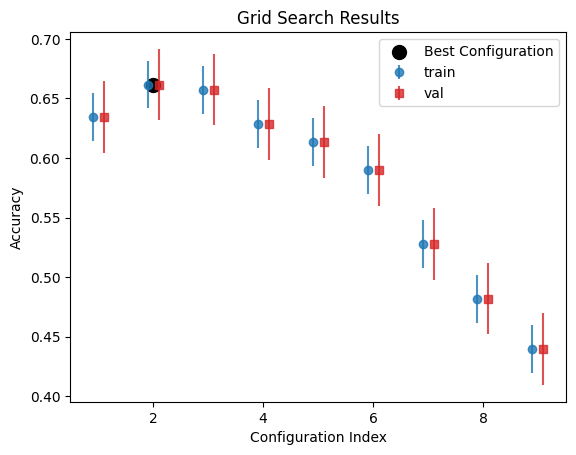

In [40]:
# Extract results from the grid search
configurations = [config for config, acc in results]
accuracies = [acc for config, acc in results]

# Simulate values for training and validation
info_accuracy_train = [(acc, acc - 0.02, acc + 0.02) for acc in accuracies]  # Simulated training accuracies
info_accuracy_val = [(acc, acc - 0.03, acc + 0.03) for acc in accuracies]  # Simulated validation accuracies

# Find the best configuration
idx_best = accuracies.index(max(accuracies))  # Index of the best accuracy
acc_max = max(accuracies)  # Best accuracy value

# Plot
plt.figure()

# Add an offset to avoid overlapping
x_train = [i - 0.1 for i in range(1, len(info_accuracy_train) + 1)]  # Offset for training data points
x_val = [i + 0.1 for i in range(1, len(info_accuracy_val) + 1)]      # Offset for validation data points

# Training data points
plt.errorbar(x_train, [info_accuracy_train[i][0] for i in range(len(info_accuracy_train))],
             yerr=([info_accuracy_train[i][0] - info_accuracy_train[i][1] for i in range(len(info_accuracy_train))],
                   [info_accuracy_train[i][2] - info_accuracy_train[i][0] for i in range(len(info_accuracy_train))]),
             marker='o',
             color='tab:blue', label='train', linestyle='', alpha=0.8)

# Validation data points
plt.errorbar(x_val, [info_accuracy_val[i][0] for i in range(len(info_accuracy_val))],
             yerr=([info_accuracy_val[i][0] - info_accuracy_val[i][1] for i in range(len(info_accuracy_val))],
                   [info_accuracy_val[i][2] - info_accuracy_val[i][0] for i in range(len(info_accuracy_val))]),
             marker='s',  # Use a different marker for validation
             color='tab:red', label='val', linestyle='', alpha=0.8)

# Highlight the best configuration
plt.scatter(idx_best + 1, acc_max, marker='o', color='black', s=100, label='Best Configuration')

# Add plot details
plt.title("Grid Search Results")
plt.xlabel('Configuration Index')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [41]:
# obtaining the best model with the best configurations
lr, batch_size = best_config[0]
batches = create_batches(X_train_t, y_train_t, batch_size)

# Initialize the model
model_NN_opt = Model_classification_multi(
    in_features=X_train_t.shape[1],
    out_features=len(torch.unique(y_train_t)),
    hidden_1=64,
    hidden_2=32,
)

# Loss function and optimizer
class_counts = torch.bincount(y_train_t)
class_weights = 1.0 / class_counts.float()
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model_NN_opt.parameters(), lr=lr)

loss_train_all = []
loss_val_all = []
acc_train_all = []
acc_val_all = []
epoch = 0

# Variables for early stopping
current_max_acc = 0
current_cumulated_epochs = 0
stop = False
max_non_improving_epochs = 2  # Stop if no improvement after 2 epochs

while not stop:
    model_NN_opt.train()
    loss_all = []

    # Training phase: Iterate over batches
    for _, (data_batch, label_batch) in enumerate(batches):
        y_prob = model_NN_opt(data_batch).squeeze()  
        loss_batch = loss_fn(y_prob, label_batch)
        loss_all.append(loss_batch.item())
        optimizer.zero_grad()  
        loss_batch.backward()  
        optimizer.step()  

    # Model evaluation phase
    model_NN_opt.eval()

    # Training set
    y_prob = model_NN_opt(X_train_t).squeeze()
    y_pred = torch.argmax(y_prob, dim=-1)  # get the label
    acc_train = accuracy_fn(y_true=y_train_t, y_pred=y_pred)

    # Validation set
    y_prob = model_NN_opt(X_val_t).squeeze()
    loss_val = loss_fn(y_prob, y_val_t)
    y_pred = torch.argmax(y_prob, dim=-1)
    acc_val = accuracy_fn(y_true=y_val_t, y_pred=y_pred)

    # Collect results
    loss = np.array(loss_all).mean()
    loss_train_all.append(loss)
    loss_val_all.append(loss_val.item())
    acc_train_all.append(acc_train)
    acc_val_all.append(acc_val)

    print(f'Epoch: {epoch} | Train Loss: {loss:.5f}, Val Loss: {loss_val:.5f}, Train Acc: {acc_train:.2f}, Val Acc: {acc_val:.2f}')

    epoch += 1

    # Early stopping condition
    if acc_val > current_max_acc:
        current_max_acc = acc_val
        current_cumulated_epochs = 0  # Reset the counter if there's an improvement
    else:
        current_cumulated_epochs += 1

    # If no improvement after 2 epochs, stop the training
    if current_cumulated_epochs >= max_non_improving_epochs:
        print(f"Early stopping due to no improvement in validation accuracy for {max_non_improving_epochs} epochs.")
        stop = True

Epoch: 0 | Train Loss: 1.38693, Val Loss: 1.19439, Train Acc: 0.59, Val Acc: 0.59
Epoch: 1 | Train Loss: 1.15908, Val Loss: 1.12319, Train Acc: 0.60, Val Acc: 0.60
Epoch: 2 | Train Loss: 1.09957, Val Loss: 1.08658, Train Acc: 0.59, Val Acc: 0.59
Epoch: 3 | Train Loss: 1.05101, Val Loss: 1.04056, Train Acc: 0.64, Val Acc: 0.64
Epoch: 4 | Train Loss: 1.02005, Val Loss: 1.00863, Train Acc: 0.64, Val Acc: 0.64
Epoch: 5 | Train Loss: 0.99632, Val Loss: 1.01087, Train Acc: 0.66, Val Acc: 0.66
Epoch: 6 | Train Loss: 0.97812, Val Loss: 1.00501, Train Acc: 0.66, Val Acc: 0.66
Epoch: 7 | Train Loss: 0.95985, Val Loss: 0.97334, Train Acc: 0.67, Val Acc: 0.67
Epoch: 8 | Train Loss: 0.94917, Val Loss: 0.95004, Train Acc: 0.67, Val Acc: 0.67
Epoch: 9 | Train Loss: 0.93737, Val Loss: 0.93935, Train Acc: 0.67, Val Acc: 0.67
Epoch: 10 | Train Loss: 0.93073, Val Loss: 0.94226, Train Acc: 0.67, Val Acc: 0.67
Epoch: 11 | Train Loss: 0.92163, Val Loss: 0.94523, Train Acc: 0.67, Val Acc: 0.66
Early stopping

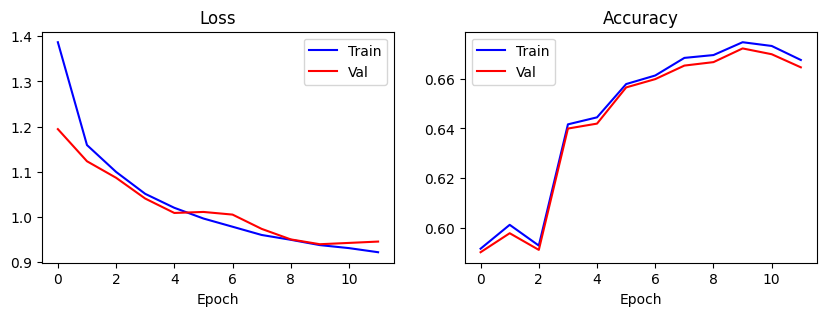

The accuracy of validation set is: 0.6645576336384136


C:\Users\calog\AppData\Local\Temp\ipykernel_31532\516269359.py:25: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  confusion = pd.pivot_table(df, index='y_true', columns='y_pred', values='samples', aggfunc=sum)


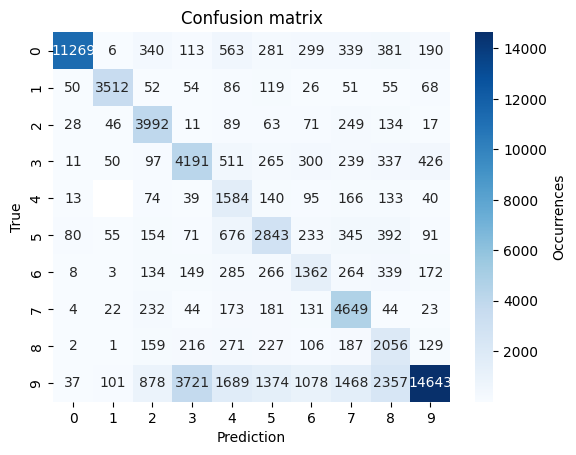

In [42]:
# printing model results

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,3))
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.plot(loss_train_all, label='Train', color='blue')
ax1.plot(loss_val_all, label='Val', color='red')
ax1.legend()
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.plot(acc_train_all, label='Train', color='blue')
ax2.plot(acc_val_all, label='Val', color='red')
ax2.legend()
plt.show()

model_NN_opt.eval()
y_prob = model_NN_opt(X_val_t).squeeze()
y_pred = torch.argmax(y_prob, dim=-1) 
acc_train = accuracy_fn(y_true=y_val_t, y_pred=y_pred)
print('The accuracy of validation set is:', acc_val_all[-1])
confusion_matrix(y_val_t, y_pred)

### Decision Tree

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split



param_grid = {
    'max_depth': range(15, 20),  
    'min_samples_split': [2, 4],
	'criterion': ['gini', 'entropy']
}
# Initialization of the model and GridSearchCV
dt = DecisionTreeClassifier(random_state=12)
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)

# fit the model and get the best parameters
grid_search.fit(X_train_scaled, y_train)
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best parameters: {best_params}")
print(f"Best cross-validated accuracy: {round(best_score,4)}")

# Train the model with the best parameters and evaluate it
best_dt = grid_search.best_estimator_
y_train_pred = best_dt.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train set accuracy: {round(train_accuracy,4)}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'criterion': 'entropy', 'max_depth': 19, 'min_samples_split': 2}
Best cross-validated accuracy: 0.8834
Train set accuracy: 0.9308


##  3.3 Classifier Evaluation

We evaluated the best Decision Tree Classifier on the test set.

In [44]:
# Evaluate on the test set
from sklearn.metrics import classification_report
y_test_pred = best_dt.predict(X_test_scaled)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     17375
           1       0.97      0.93      0.95      5020
           2       0.96      0.93      0.95      5807
           3       0.84      0.71      0.76      8052
           4       0.89      0.80      0.84      2896
           5       0.89      0.83      0.86      6131
           6       0.86      0.70      0.77      3652
           7       0.98      0.97      0.97      6894
           8       0.87      0.75      0.81      4254
           9       0.91      0.92      0.92     34156

   micro avg       0.92      0.89      0.91     94237
   macro avg       0.91      0.85      0.88     94237
weighted avg       0.92      0.89      0.90     94237
 samples avg       0.89      0.89      0.89     94237



c:\Users\calog\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


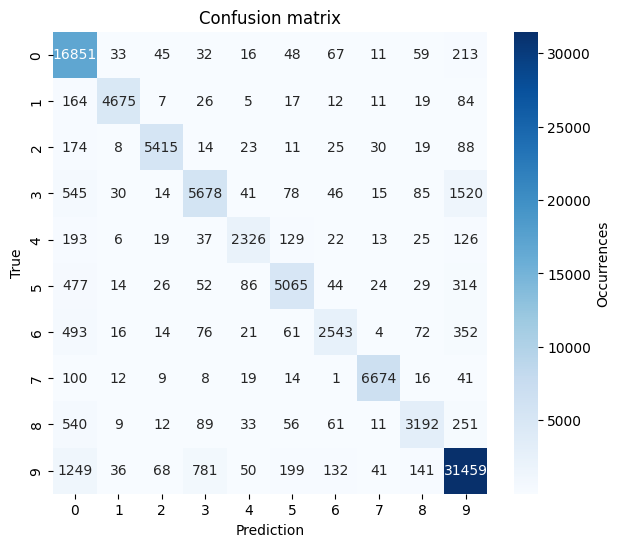

In [45]:
# get the confusion matrix of test set
from sklearn.metrics import confusion_matrix

# Convert one-hot encoded arrays to single-label class indices
y_test_single = np.argmax(y_test, axis=1)
y_pred_single = np.argmax(y_test_pred, axis=1)

confusion = confusion_matrix(y_test_single, y_pred_single)

# visualize the confusion matrix
plt.figure(figsize=(7,6))
sns.heatmap(confusion, cmap='Blues', annot=True, cbar_kws={'label':'Occurrences'}, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

c:\Users\calog\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


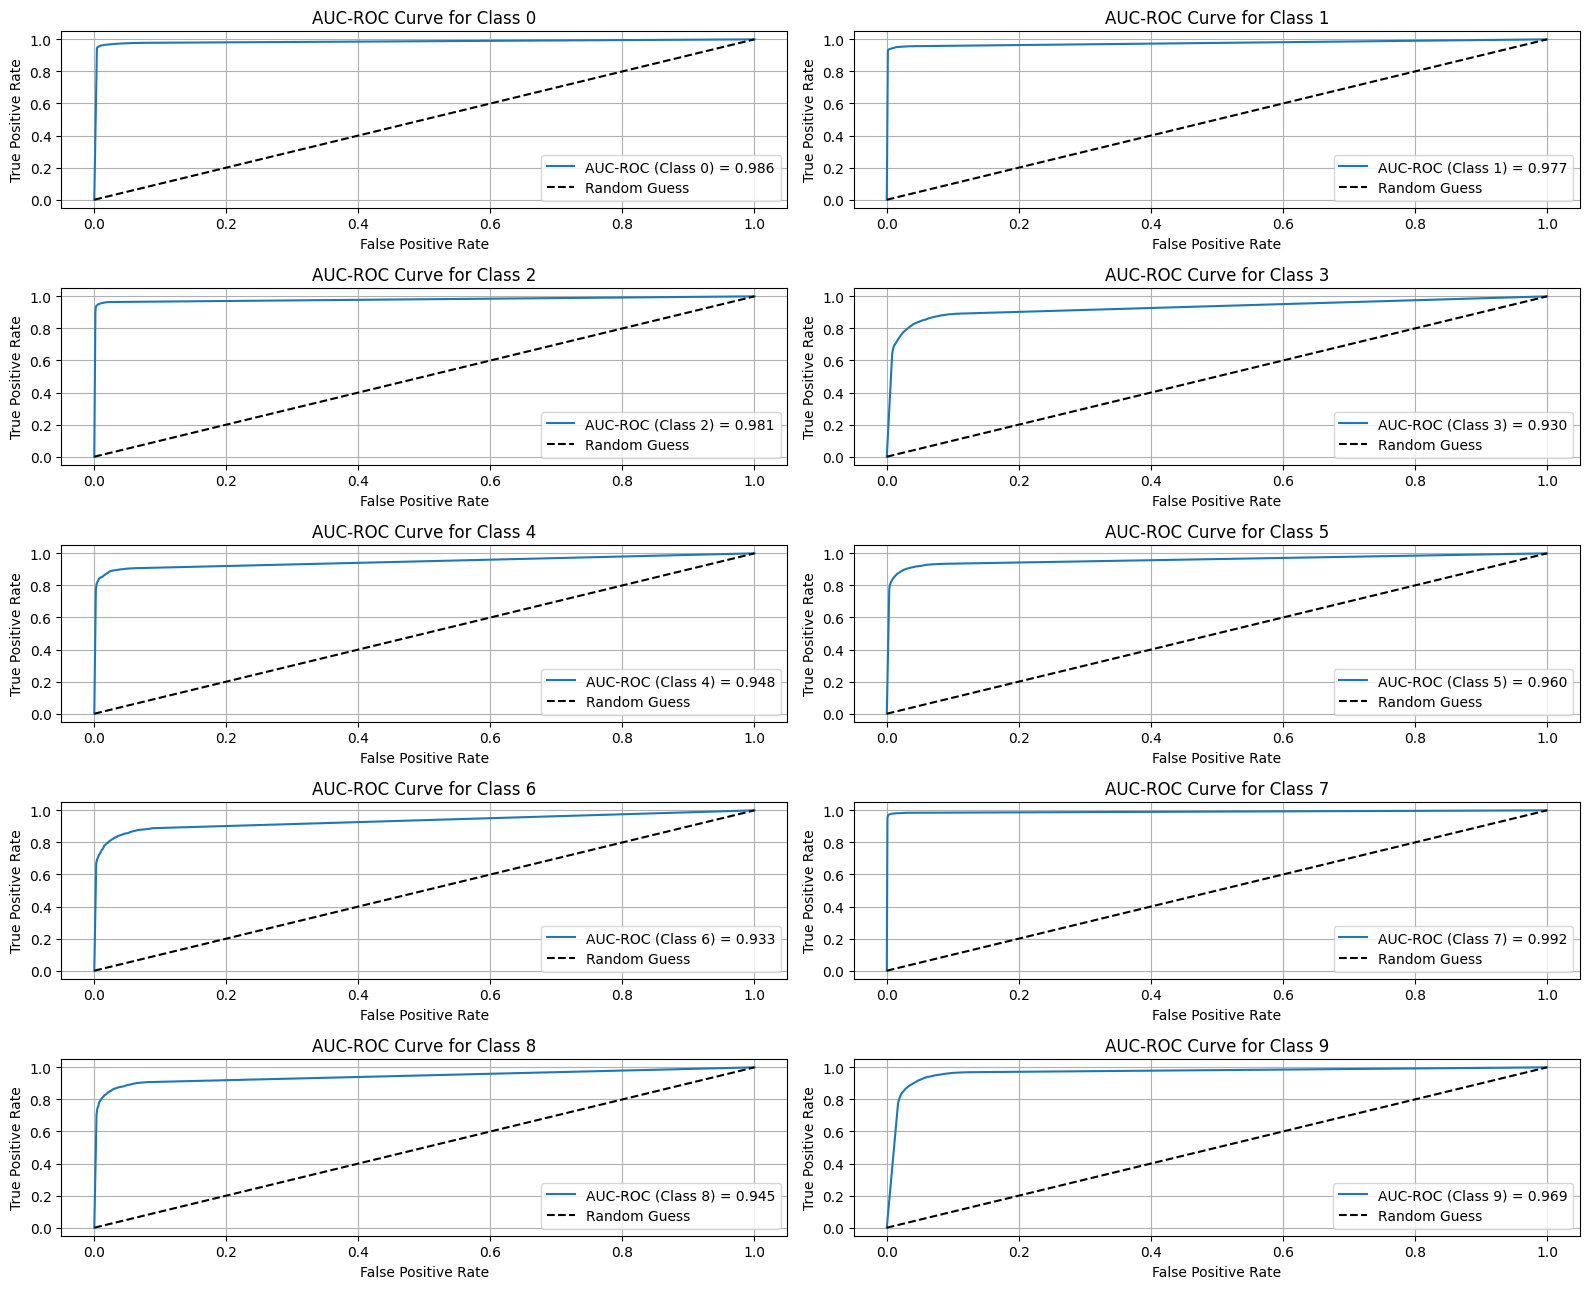

In [46]:
from sklearn.metrics import roc_auc_score, roc_curve


y_prob_full = np.array(best_dt.predict_proba(x_test_scaled_df))  # Shape: (10, 94237, 2)

fig, axes = plt.subplots(5, 2, figsize=(16, 13))
axes = axes.ravel()  # Flatten the 2D array of axes into 1D for easy indexing

for target_class in range(10):
    # Binary labels for the current class
    y_test_binary = y_test[:, target_class].ravel()
    # Extract probabilities for the positive class (1) of the target class
    y_prob = y_prob_full[target_class, :, 1]
    # Compute ROC curve and AUC score
    fpr, tpr, _ = roc_curve(y_test_binary, y_prob)
    auc_roc = roc_auc_score(y_test_binary, y_prob)

    # Plot the AUC-ROC curve
    ax = axes[target_class]
    ax.plot(fpr, tpr, label=f"AUC-ROC (Class {target_class}) = {auc_roc:.3f}")
    ax.plot([0, 1], [0, 1], 'k--', label="Random Guess")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"AUC-ROC Curve for Class {target_class}")
    ax.legend(loc="lower right")
    ax.grid()

plt.tight_layout()
plt.show()


#   4. Adversarial Attacks

## 4.1 Random Noise

Define the function to add random noise to the test data.

In [47]:
def add_noise(data, epsilon):
    # Generate random noise from a normal distribution
    noise = torch.randn_like(data)
    
    # Compute the norm for each sample (row-wise)
    norm = torch.norm(noise, dim=1, keepdim=True)
    
    # Scale the noise to have the desired epsilon norm
    scaled_noise = (epsilon / norm) * noise
    
    # Add the scaled noise to the data
    noisy_data = data + scaled_noise
    
    # Clip the values to ensure they are within the valid range [0, 1]
    noisy_data = torch.clamp(noisy_data, 0, 1)
    
    return noisy_data

Apply random noise to test data varying the intensity epsilon.

In [48]:
epsilon_values = [0.01, 0.2, 0.4, 0.6, 0.8, 1.0]
noisy_test_set = [add_noise(X_test_t, epsilon) for epsilon in epsilon_values]

Evaluate the classifier on noisy data.

In [49]:
robust_accuracies = []

for noisy_test_data in noisy_test_set:
    model_NN_opt.eval()
    y_prob = model_NN_opt(noisy_test_data).squeeze()
    y_pred = torch.argmax(y_prob, dim=-1)
    accuracy = accuracy_fn(y_test_t, y_pred) * 100
    robust_accuracies.append(accuracy)

Plot the degradation in accuracy with respect to noise intensity (epsilon).

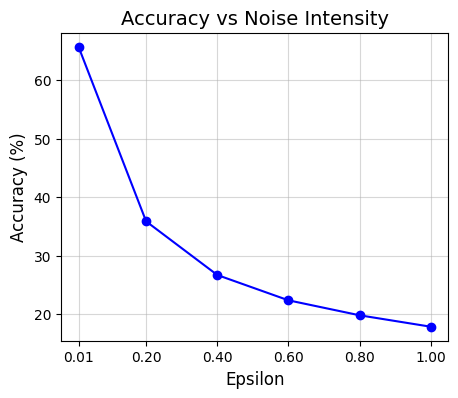

In [50]:
plt.figure(figsize=(5, 4))
plt.plot(epsilon_values, robust_accuracies, marker='o', linestyle='-', color='b')
plt.title(f'Accuracy vs Noise Intensity', fontsize=14)
plt.xlabel('Epsilon', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(epsilon_values)
plt.grid(alpha=0.5)
plt.show()

## 4.2 Feature Specific Noise

Define the function to add random noise only to a specific feature of the test data.

In [51]:
def add_noise_to_feature(data, feature, epsilon):
    # Extract the column related to the selected feature
    column = data[f'{feature}'].to_numpy()
    
    # Generate random noise from a normal distribution
    noise = torch.randn_like(torch.tensor(column, dtype=torch.float))
    
    # Compute the norm
    norm = torch.norm(noise, keepdim=True)
    
    # Scale noise to the desired epsilon
    scaled_noise = (epsilon / norm) * noise
    
    # Add the scaled noise to the selected feature
    noisy_column = column + scaled_noise.numpy()
    
    # Update the column in the dataset
    noisy_data = data.copy()
    noisy_data[f'{feature}'] = noisy_column
    
    # Convert the noisy_data to a tensor
    noisy_data = torch.tensor(noisy_data.to_numpy(), dtype=torch.float)
    
    # Clip the values to ensure they are within the valid range [0, 1]
    noisy_data = torch.clamp(noisy_data, 0, 1)
    
    return noisy_data

Evaluate the classifier on noisy data.

In [52]:
robust_accuracies = []
features = x_test_scaled_df.columns

for epsilon in epsilon_values:
    for feature in features:
        # Add noise to the selected feature
        noisy_test_data = add_noise_to_feature(x_test_scaled_df, feature, epsilon)

        # Compute the accuracy on the noisy dataset
        model_NN_opt.eval()
        y_prob = model_NN_opt(noisy_test_data).squeeze()
        y_pred = torch.argmax(y_prob, dim=-1)
        accuracy = accuracy_fn(y_test_t, y_pred) * 100
        
        robust_accuracies.append((epsilon, feature, accuracy))

Build a grid to look for the most vulnerable feature, i.e. the one that resulted in the greatest degradation of accuracy.

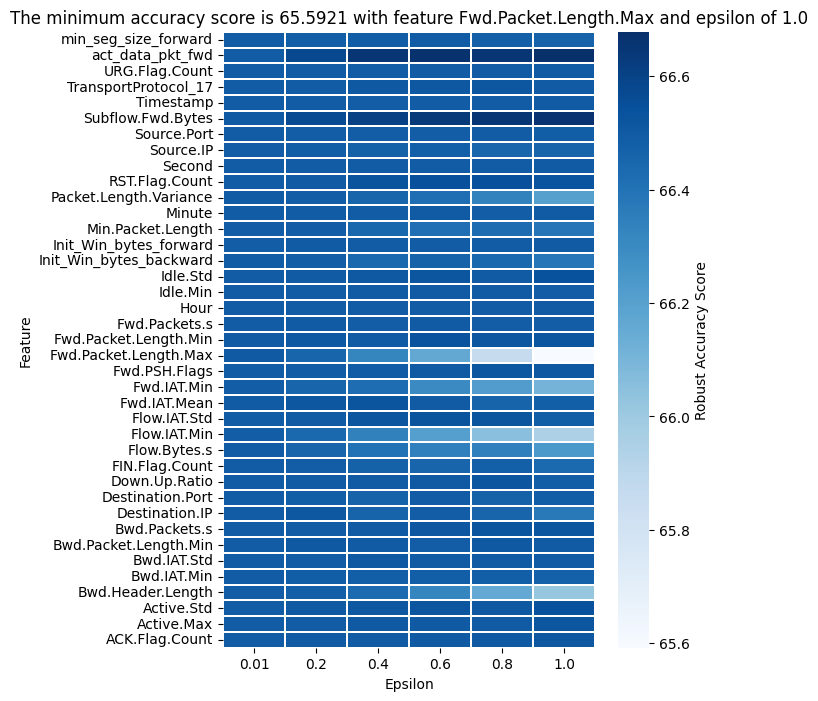

In [53]:
gs = pd.DataFrame(robust_accuracies, columns=['Epsilon', 'Feature', 'acc'])
gs = pd.pivot_table(gs, columns='Epsilon', index='Feature', values='acc', aggfunc=lambda x:x)

min_acc = gs.min().min()
feature_min_acc = gs.stack().idxmin()[0]
eps_min_acc = gs.stack().idxmin()[1]

plt.figure(figsize=(6,8))
plt.title(f'The minimum accuracy score is {round(min_acc, 4)} with feature {feature_min_acc} and epsilon of {eps_min_acc}')
sns.heatmap(gs, cmap='Blues', cbar_kws={'label':'Robust Accuracy Score'}, linewidths=.005)
plt.gca().invert_yaxis()
plt.show()

Finally we show accuracy values for various epsilon values applied to the most vulnerable feature.

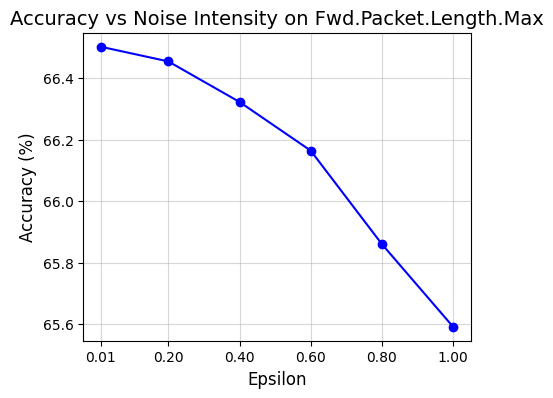

In [54]:
most_vuln_feature = gs.loc[f'{feature_min_acc}']

plt.figure(figsize=(5, 4))
plt.plot(epsilon_values, most_vuln_feature, marker='o', linestyle='-', color='b')
plt.title(f'Accuracy vs Noise Intensity on {feature_min_acc}', fontsize=14)
plt.xlabel('Epsilon', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(epsilon_values)
plt.grid(alpha=0.5)
plt.show()

##  4.3 Adversarial Attack with ART

In [55]:
# de-comment if need to install
!python -m pip install adversarial-robustness-toolbox

You should consider upgrading via the 'c:\Users\calog\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [56]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent
from art.estimators.classification import PyTorchClassifier

# Loss function and optimizer
class_counts = torch.bincount(y_train_t)
class_weights = 1.0 / class_counts.float()
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model_NN_opt.parameters(), lr=lr)

classifier = PyTorchClassifier(
    model=model_NN_opt,
    clip_values=(0.0, 1.0),
    loss=loss_fn,
    optimizer=optimizer,
    input_shape=(X_train_t.shape[1]),  
    nb_classes=len(np.unique(y_train_t)),
)

print(X_test_t.shape)
print(y_test_t.shape)
print(X_train_t.shape[1])
lr, batch_size = best_config[0]

torch.Size([94237, 39])
torch.Size([94237])
39


In [57]:
# prediction for test data
predictions = classifier.predict(X_test_t)
predictions_class = torch.argmax(torch.tensor(predictions), dim=1)


accuracy = torch.sum(predictions_class == y_test_t) / len(y_test_t)
accuracies.append(accuracy.item() * 100)  # Convert accuracy to percentage
print("Test accuracy on test sample: %.2f%%" % (accuracy * 100))

Test accuracy on test sample: 66.49%




FastGradientSignMethod - FGSM


Test accuracy on adversarial sample with FGSM (epsilon = 0.01): 32.88%
Test accuracy on adversarial sample with FGSM (epsilon = 0.05): 18.12%
Test accuracy on adversarial sample with FGSM (epsilon = 0.10): 14.22%
Test accuracy on adversarial sample with FGSM (epsilon = 0.20): 9.57%
Test accuracy on adversarial sample with FGSM (epsilon = 0.30): 9.07%


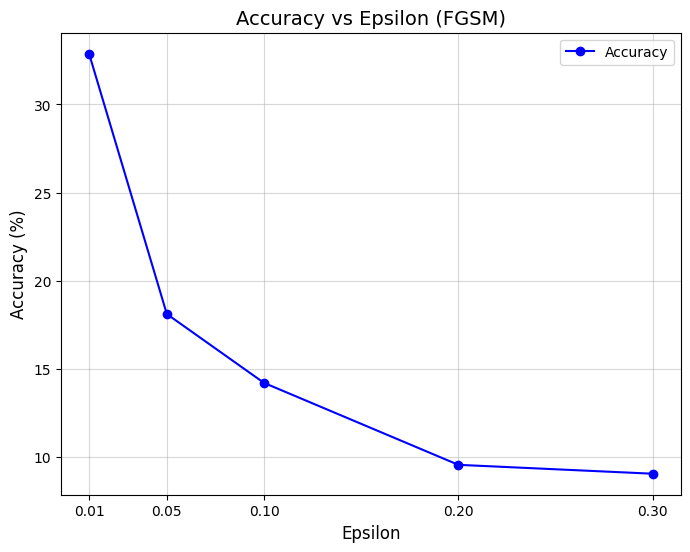

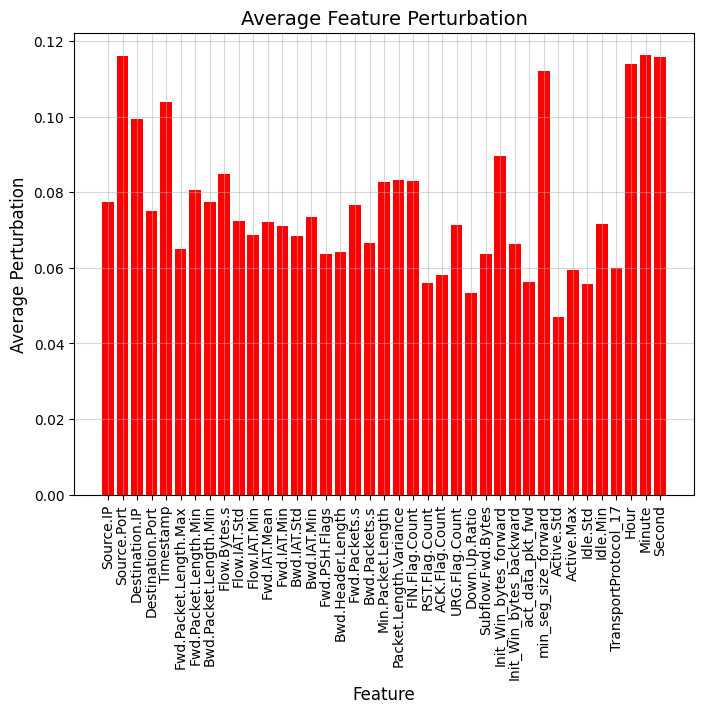

In [58]:
def calculate_feature_perturbation(X_original, X_adversarial):
    # Calculate the difference between adversarial and original samples
    perturbations = X_adversarial - X_original
    # Compute the average perturbation for each feature
    feature_perturbations = torch.abs(perturbations).mean(dim=0)
    return feature_perturbations

# Define epsilon values and feature names
feature_names = X_train_1.columns.tolist()
epsilon_values = [0.01, 0.05, 0.1, 0.2, 0.3]
accuracies = []
perturbation_means = []

# Iterate over epsilon values
for epsilon in epsilon_values:
    # Craft adversarial samples with FGSM
    adv_crafter = FastGradientMethod(estimator=classifier, batch_size=batch_size, eps=epsilon)
    x_test_adv_fgsm = adv_crafter.generate(x=X_test_t.numpy(), y=y_test_t.numpy())  # Convert to NumPy

    # Evaluate the classifier on adversarial examples
    predictions = classifier.predict(x_test_adv_fgsm)
    predictions_class = torch.argmax(torch.tensor(predictions), dim=1)

    accuracy = torch.sum(predictions_class == y_test_t) / len(y_test_t)
    accuracies.append(accuracy.item() * 100)  # Convert accuracy to percentage
    print("Test accuracy on adversarial sample with FGSM (epsilon = %.2f): %.2f%%" % (epsilon, accuracy * 100))

    # Calculate perturbations for each feature
    perturbations = calculate_feature_perturbation(X_test_t.clone().detach(), torch.tensor(x_test_adv_fgsm).clone().detach())
    perturbation_means.append(perturbations)

# Plot accuracy vs epsilon
plt.figure(figsize=(8, 6))
plt.plot(epsilon_values, accuracies, marker='o', linestyle='-', color='b', label='Accuracy')
plt.title('Accuracy vs Epsilon (FGSM)', fontsize=14)
plt.xlabel('Epsilon', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(epsilon_values)
plt.grid(alpha=0.5)
plt.legend(fontsize=10)
plt.show()

# Convert results to a NumPy array for easier visualization
perturbation_means = np.array(perturbation_means)

# Calculate the average perturbation across all epsilon values
avg_perturbation = perturbation_means.mean(axis=0)

# Plot average feature perturbation
plt.figure(figsize=(8, 6))
plt.bar(feature_names, avg_perturbation, color='r')
plt.title('Average Feature Perturbation', fontsize=14)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Average Perturbation', fontsize=12)
plt.xticks(rotation=90)
plt.grid(alpha=0.5)
plt.show()

Projected Gradient Descent - PGD

PGD - Batches:   0%|          | 0/2945 [00:00<?, ?it/s]

Test accuracy on adversarial sample with PGD (epsilon = 0.01): 22.14%


PGD - Batches:   0%|          | 0/2945 [00:00<?, ?it/s]

Test accuracy on adversarial sample with PGD (epsilon = 0.05): 15.07%


PGD - Batches:   0%|          | 0/2945 [00:00<?, ?it/s]

Test accuracy on adversarial sample with PGD (epsilon = 0.10): 9.24%


PGD - Batches:   0%|          | 0/2945 [00:00<?, ?it/s]

Test accuracy on adversarial sample with PGD (epsilon = 0.20): 5.68%


PGD - Batches:   0%|          | 0/2945 [00:00<?, ?it/s]

Test accuracy on adversarial sample with PGD (epsilon = 0.30): 5.58%


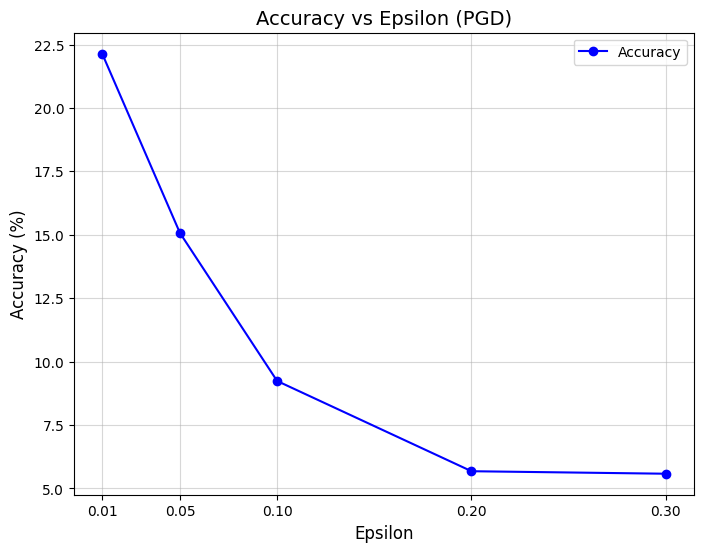

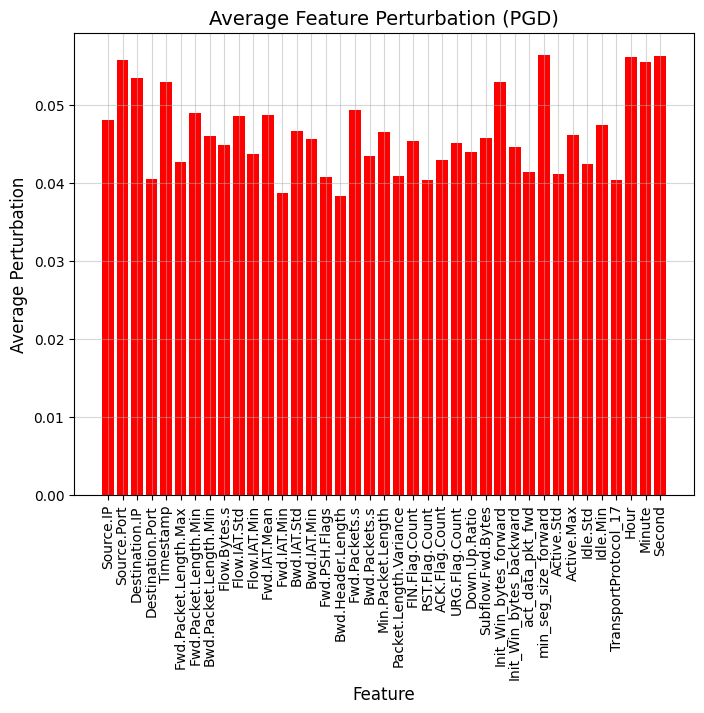

In [59]:
perturbation_means = []
accuracies = []

# Iterate over epsilon values
for epsilon in epsilon_values:
    # Generate adversarial samples using Projected Gradient Descent (PGD)
    adv_crafter = ProjectedGradientDescent(estimator=classifier, eps=epsilon, max_iter=5, eps_step=0.05)
    x_test_adv_pgd = adv_crafter.generate(x=X_test_t.numpy(), y=y_test_t.numpy())  # Convert tensor to NumPy for ART

    # Predict using the classifier on adversarial examples
    predictions = classifier.predict(x_test_adv_pgd)
    predictions_class = torch.argmax(torch.tensor(predictions), dim=1)

    # Calculate accuracy on adversarial samples
    accuracy = torch.sum(predictions_class == y_test_t) / len(y_test_t)
    accuracies.append(accuracy.item() * 100)  # Convert accuracy to percentage
    print("Test accuracy on adversarial sample with PGD (epsilon = %.2f): %.2f%%" % (epsilon, accuracy * 100))

    # Calculate the average perturbation for each feature
    perturbations = calculate_feature_perturbation(X_test_t.clone().detach(), torch.tensor(x_test_adv_pgd).clone().detach())
    perturbation_means.append(perturbations)

# Convert perturbation results to a NumPy array for easier visualization
perturbation_means = np.array(perturbation_means)

# Calculate the average perturbation across all epsilon values
avg_perturbation = perturbation_means.mean(axis=0)

# Plot accuracy as a function of epsilon values
plt.figure(figsize=(8, 6))
plt.plot(epsilon_values, accuracies, marker='o', linestyle='-', color='b', label='Accuracy')
plt.title('Accuracy vs Epsilon (PGD)', fontsize=14)
plt.xlabel('Epsilon', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(epsilon_values)
plt.grid(alpha=0.5)
plt.legend(fontsize=10)
plt.show()

# Plot average perturbations for each feature with feature names
plt.figure(figsize=(8, 6))
plt.bar(feature_names, avg_perturbation, color='r')
plt.title('Average Feature Perturbation (PGD)', fontsize=14)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Average Perturbation', fontsize=12)
plt.xticks(rotation=90)  # Rotate feature names vertically
plt.grid(alpha=0.5)
plt.show()

##  4.4 Countermeasure Exploration

In [60]:
from art.defences.trainer import AdversarialTrainer

fgsm_attacks = [FastGradientMethod(estimator=classifier, eps=eps) for eps in epsilon_values]
pgd_attack = [ProjectedGradientDescent(estimator=classifier, eps=eps, max_iter=5) for eps in epsilon_values]
all_attacks = fgsm_attacks + pgd_attack

adversarial_trainer = AdversarialTrainer(classifier=classifier, attacks=all_attacks, ratio=0.4)
adversarial_trainer.fit(X_test_t.numpy(), y_test_t.numpy(), nb_epochs=10, batch_size=batch_size)

Precompute adv samples:   0%|          | 0/10 [00:00<?, ?it/s]

Adversarial training epochs:   0%|          | 0/10 [00:00<?, ?it/s]

In [61]:
# valuating the updated model on clean test data
predictions = classifier.predict(X_test_t.numpy())
accuracy_clean = (torch.argmax(torch.tensor(predictions), dim=1) == y_test_t).float().mean().item()
print(f"Accuracy on clean test data: {accuracy_clean * 100:.2f}%")

Accuracy on clean test data: 64.07%


Test accuracy of the new model on new adversarial sample with FGSM (epsilon = 0.01): 43.87%
Test accuracy of the new model on new adversarial sample with FGSM (epsilon = 0.05): 30.67%
Test accuracy of the new model on new adversarial sample with FGSM (epsilon = 0.10): 26.48%
Test accuracy of the new model on new adversarial sample with FGSM (epsilon = 0.20): 26.56%
Test accuracy of the new model on new adversarial sample with FGSM (epsilon = 0.30): 22.47%


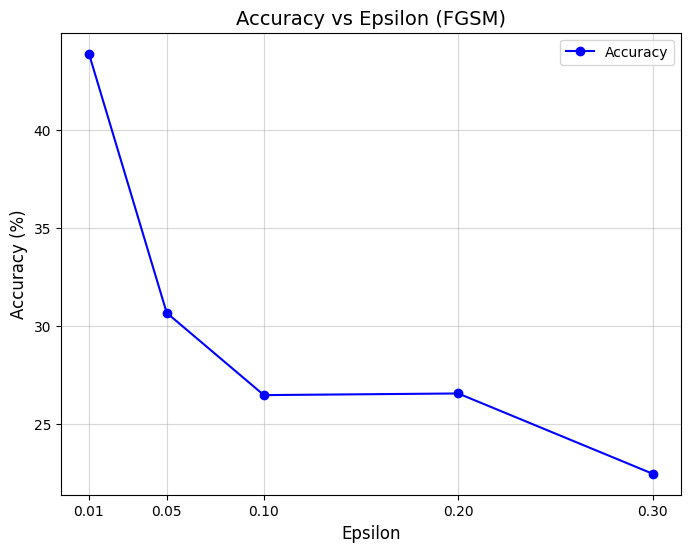

In [62]:
#fgsm
accuracies = []

for epsilon in epsilon_values:
    # Craft adversarial samples with FGSM
    adv_crafter = FastGradientMethod(estimator=classifier, eps=epsilon)
    x_test_adv_fgsm = adv_crafter.generate(x=X_val_t.numpy(), y=y_val_t.numpy())  

    # Evaluate the classifier on adversarial examples
    predictions = classifier.predict(x_test_adv_fgsm)
    predictions_class = torch.argmax(torch.tensor(predictions), dim=1)

    accuracy = torch.sum(predictions_class == y_val_t) / len(y_val_t)
    accuracies.append(accuracy.item() * 100)  # Convert accuracy to percentage
    print("Test accuracy of the new model on new adversarial sample with FGSM (epsilon = %.2f): %.2f%%" % (epsilon, accuracy * 100))


# Plot accuracy vs epsilon
plt.figure(figsize=(8, 6))
plt.plot(epsilon_values, accuracies, marker='o', linestyle='-', color='b', label='Accuracy')
plt.title('Accuracy vs Epsilon (FGSM)', fontsize=14)
plt.xlabel('Epsilon', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(epsilon_values)
plt.grid(alpha=0.5)
plt.legend(fontsize=10)
plt.show()

PGD - Batches:   0%|          | 0/2356 [00:00<?, ?it/s]

Test accuracy of the new model on bew adversarial sample with PGD (epsilon = 0.01): 38.32%


PGD - Batches:   0%|          | 0/2356 [00:00<?, ?it/s]

Test accuracy of the new model on bew adversarial sample with PGD (epsilon = 0.05): 26.66%


PGD - Batches:   0%|          | 0/2356 [00:00<?, ?it/s]

Test accuracy of the new model on bew adversarial sample with PGD (epsilon = 0.10): 17.59%


PGD - Batches:   0%|          | 0/2356 [00:00<?, ?it/s]

Test accuracy of the new model on bew adversarial sample with PGD (epsilon = 0.20): 13.10%


PGD - Batches:   0%|          | 0/2356 [00:00<?, ?it/s]

Test accuracy of the new model on bew adversarial sample with PGD (epsilon = 0.30): 12.83%


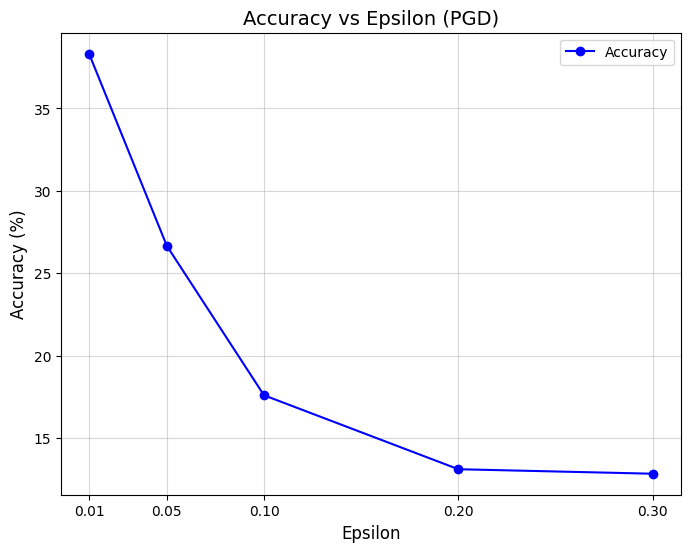

In [63]:
#pgd
accuracies = []

# Iterate over epsilon values
for epsilon in epsilon_values:
    # Generate adversarial samples using Projected Gradient Descent (PGD)
    adv_crafter = ProjectedGradientDescent(estimator=classifier, eps=epsilon, max_iter=5, eps_step=0.05)
    x_test_adv_pgd = adv_crafter.generate(x=X_val_t.numpy(), y=y_val_t.numpy())  # Convert tensor to NumPy for ART

    # Predict using the classifier on adversarial examples
    predictions = classifier.predict(x_test_adv_pgd)
    predictions_class = torch.argmax(torch.tensor(predictions), dim=1)

    # Calculate accuracy on adversarial samples
    accuracy = torch.sum(predictions_class == y_val_t) / len(y_val_t)
    accuracies.append(accuracy.item() * 100)  # Convert accuracy to percentage
    print("Test accuracy of the new model on bew adversarial sample with PGD (epsilon = %.2f): %.2f%%" % (epsilon, accuracy * 100))

# Plot accuracy as a function of epsilon values
plt.figure(figsize=(8, 6))
plt.plot(epsilon_values, accuracies, marker='o', linestyle='-', color='b', label='Accuracy')
plt.title('Accuracy vs Epsilon (PGD)', fontsize=14)
plt.xlabel('Epsilon', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(epsilon_values)
plt.grid(alpha=0.5)
plt.legend(fontsize=10)
plt.show()